In [24]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [25]:
import os 
import sys 
sys.path.append('..')
print(os.getcwd())
import matplotlib.pyplot as plt 
import numpy as np
import torch
from pathlib import Path

import hippocampalseq as hse
import hippocampalseq.utils as hseu
import hippocampalseq.preprocessing as hsep
import hippocampalseq.models as hsem
import hippocampalseq.plotting as hsepl
import hippocampalseq.analysis as hsea


/project/bioinformatics/WZhang_lab/s437598/PO-OU/notebooks


In [26]:
BASE_DIR =  "/work/bioinformatics/s437598/New_Brad_Data/_CleanDataSetForSharing"
data_path = BASE_DIR

In [28]:
theta_time_window_s  = 20/1000#60 / 1000
theta_time_window_advance_s  = 5/1000#60 / 1000

ripple_time_window_s  = 3.0 / 1000


bin_size = 2
#data_path = os.path.realpath("../data")
rat_name = "Janni"
session = 1
track_type = "Linear"

if track_type == "Linear":
    environment_size = None
else:
    environment_size =  hsep.EnvironmentSize((0,200), (0,200))

nplot = 20

In [29]:
(raw_data, place_field_data) = hse.load_raw_data(
    data_path, rat_name, session,
    track_type=track_type, environment_size=environment_size, bin_size_cm=bin_size,
    placefield_kwargs={'place_field_posterior': False,
                    'velocity_cutoff': 5.0,             # paper: fields from >= 5 cm/s
                    'place_field_gaussian_sd_cm': 4.0,  # paper: sigma = 4 cm
                    'flatten_linear': True},
)
theta_data = hse.process_theta(
    raw_data, place_field_data, velocity_cutoff=10.0,
    theta_kwargs={'time_window_s': theta_time_window_s,
                'time_window_advance_s': theta_time_window_advance_s},
)
place_fields = place_field_data.place_fields[place_field_data.place_cell_ids]
print(place_fields.shape, theta_data.spikes[0].shape)     # cell counts must match

%store raw_data place_field_data theta_data

/home2/s437598/miniconda3/envs/hippocampalswr/lib/python3.14/site-packages/pynapple/core/base_class.py:50: UserWarning: Some epochs have no duration
  self.time_support = IntervalSet(start=self.index[0], end=self.index[-1])
/home2/s437598/miniconda3/envs/hippocampalswr/lib/python3.14/site-packages/pynapple/core/base_class.py:52: RuntimeWarning: divide by zero encountered in scalar divide
  self.rate = self.index.shape[0] / np.sum(
/home2/s437598/miniconda3/envs/hippocampalswr/lib/python3.14/site-packages/pynapple/core/base_class.py:50: UserWarning: Some epochs have no duration
  self.time_support = IntervalSet(start=self.index[0], end=self.index[-1])
/home2/s437598/miniconda3/envs/hippocampalswr/lib/python3.14/site-packages/pynapple/core/base_class.py:52: RuntimeWarning: divide by zero encountered in scalar divide
  self.rate = self.index.shape[0] / np.sum(
/home2/s437598/miniconda3/envs/hippocampalswr/lib/python3.14/site-packages/pynapple/core/base_class.py:50: UserWarning: Some epoch

Sample rate: nominal=3255.60 Hz, actual median dt=3255.2166 Hz, drift=+117.8 ppm
LFP data range: 3885.0 - 11772.3s (duration: 7887.3s)
Found 1 run session(s)
  Session 1:
    Position: 5688.1 - 6867.9s
    Spikes:   5688.1 - 6867.9s


/project/bioinformatics/WZhang_lab/s437598/PO-OU/notebooks/../hippocampalseq/io/lfp.py:174: UserWarning:     -> overlap 5688.1 - 6867.9s
  warnings.warn(f'    -> overlap {overlap_start:.1f} - {overlap_end:.1f}s')


Loading data took 20.06927466392517s
Calculating place fields took 0.10658383369445801s
Dropping LFP metadata. If you want it, call the functions yourself


/project/bioinformatics/WZhang_lab/s437598/PO-OU/notebooks/../hippocampalseq/preprocessing/theta.py:269: UserWarning: 0/8574 theta cycles boundary-rejected
  warnings.warn(f"{n_skipped_boundary}/{n_valid} theta cycles boundary-rejected")
/project/bioinformatics/WZhang_lab/s437598/PO-OU/notebooks/../hippocampalseq/preprocessing/theta.py:270: UserWarning: 1050/8574 theta cycles length filtered
  warnings.warn(f"{n_skipped_length}/{n_valid} theta cycles length filtered")


Detecting theta cycles took 0.6342787742614746s
Matched 428604 spikes to LFP. |Δt| (median/IQR): 0.08 ms / 0.08 ms
Aligning spikes to theta phase took 0.4994378089904785
Extracting theta run sequences took 1.4515681266784668
(89, 89, 1) (703, 89)
Stored 'raw_data' (RawData)
Stored 'place_field_data' (PlaceFields)
Stored 'theta_data' (Theta)


In [30]:
print(place_fields.shape, theta_data.spikes[0].shape)     # cell counts must match


(89, 89, 1) (703, 89)


In [31]:
bmap = hsem.BayesianMAP(
    place_fields=place_fields,
    dt=theta_time_window_s,
    bin_size=bin_size
)
map_decoded = bmap.fit(theta_data.spikes)

In [32]:
def bin_posterior_phase_gaussian(
    decoded_trajectory: list[np.ndarray],
    decoded_cumulative_probability: list[np.ndarray],
    spikemats: list[np.ndarray],
    environment_size: hsep.EnvironmentSize,
    segments: list[nap.TsdFrame],
    *,
    spike_count_percentile: float = 66.67,
    bin_size_cm: int = 2,
    phase_bin_width: int = 10,
    distance_edges=None,
):
    phase_col = 'Phase Deg'
    head_direction_col = 'Head direction'

    oscillation_spikes = []
    for gt in theta_data.ground_truth:
        oscs = set(gt['Oscillation Number'])
        oscillation_spikes.append(
        )


In [33]:
momentum = hsem.Momentum(
    dt=theta_time_window_s,
    bin_size=bin_size,
    environment_size=raw_data.environment_size,
    place_fields=place_fields,
    spikemat_train=theta_data.spikes
)
momentum_results= momentum.fit()

Iteration 0: Training loglike=-419599.8095
Iteration 20: Training loglike=-320305.4246
Training converged after 29 epochs, exiting


In [34]:
import numpy as np
import pynapple as nap
from scipy.stats import multivariate_normal

def bin_posterior_phase_gaussian(
    posterior_means: list[np.ndarray],
    posterior_covariances: list[np.ndarray]|None,
    environment_size: hsep.EnvironmentSize,
    segments: list[nap.TsdFrame],
    *,
    phase_col: str = "Phase Deg",
    head_direction_col: str ="Head direction",
    bin_size_cm: int = 2,
    phase_bin_width: int = 10,
    distance_edges=None,
):
    """
    Evaluate posterior distributions across an environment, compute signed
    point-to-subject distances, and aggregate posterior-weighted distances by
    oscillation phase.

    A point is assigned a positive distance if it is in front of the subject's
    head direction, and a negative distance if it is behind. "In front" is
    determined by the dot product between the point displacement vector and
    the unit head-direction vector.

    Args: 
        posterior_means (list[np.ndarray]): One posterior mean per time step. 
        posterior_covariances (list[np.ndarray]|None): One posterior covariance per time step. If None, set to 0 covariance.
        environment_size (hsep.EnvironmentSize): Size of the environment.
        true_dfs (list[nap.TsdFrame]): True position, head direction, and theta phase columns must be included.
        phase_col (str): Column containing wave phase in degrees. Defaults to 'Phase Deg'.
        head_direction_col (str): Column containing head direction in degrees, where 0° points along +x
            and angles increase counter-clockwise. Defaults to 'Head direction'.
        bin_size_cm (float): Size of each spatial bin in centimeters. Defaults to 2.
        phase_bin_width (float): Width of phase bins in degrees. Defaults to 10.

    Returns:

    """
    if posterior_covariances is None:
        # Good for point estimates
        posterior_covariances = [
            np.zeros((len(m), m.shape[1], m.shape[1]))
            for m in posterior_means
        ]
    if not (
        len(posterior_means)
        == len(posterior_covariances)
        == len(segments)
    ):
        raise ValueError(
            "posterior_means, posterior_covariances, and segments "
            "must have the same number of elements."
        )

    position_cols = environment_size.axes()

    grid_points = hseu.make_ndgrid(environment_size, bin_size_cm).numpy()
    spatial_dim = len(environment_size)
    if len(environment_size) == 1:
        axis = environment_size.x if environment_size.x else environment_size.y
        max_distance = axis[1] - axis[0]
        cell_volume = max_distance / (len(grid_points) - 1)
    else:
        x = environment_size.x
        y = environment_size.y
        max_distance = np.hypot(
            x[1] - x[0],
            y[1] - y[0]
        )
        cell_volume = (
            (x[1] - x[0]) / (len(np.unique(grid_points[:, 0])) - 1)
            * (y[1] - y[0]) / (len(np.unique(grid_points[:, 1])) - 1)
        )

    if distance_edges is None:
        distance_edges = np.linspace(-max_distance, max_distance, 101)
    else:
        distance_edges = np.asarray(distance_edges, dtype=float)

    if np.any(np.diff(distance_edges) <= 0):
        raise ValueError("distance_edges must be strictly increasing.")

    phase_edges = np.arange(0.0, 360.0 + phase_bin_width, phase_bin_width)
    n_distance_bins = len(distance_edges) - 1
    n_phase_bins = len(phase_edges) - 1

    posterior_mass = np.zeros((n_phase_bins, n_distance_bins), dtype=float)
    phase_counts = np.zeros(n_phase_bins, dtype=int)

    for means_segment, covs_segment, frame in zip(
        posterior_means,
        posterior_covariances,
        segments,
    ):
        if means_segment.ndim == 3:
            means_segment = np.squeeze(means_segment, axis=-1)
        means_segment = hseu.atleast_2d(means_segment)

        if means_segment.shape[1] != spatial_dim:
            raise ValueError(
                f"Means have dimension {means_segment.shape[1]}, but "
                f"environment_size describes a {spatial_dim}D space."
            )

        phase = np.mod(frame[phase_col].values, 360.0)
        head_direction = np.deg2rad(frame[head_direction_col].values)

        true_position = hseu.atleast_2d(frame[position_cols])
        # one sign per segment: +1 if the rat ran toward +axis, -1 otherwise
        run_direction = 1.0 if (true_position[-1, 0] - true_position[0, 0]) >= 0 else -1.0
        n_time = len(means_segment)
        if not (
            len(phase) == len(head_direction) == len(true_position) == n_time
            and covs_segment.shape[0] == n_time
        ):
            raise ValueError(
                "Each segment's posterior arrays and TsdFrame must have "
                "the same number of time points."
            )

        phase_bin = np.clip(
            np.digitize(phase, phase_edges, right=False) - 1,
            0,
            n_phase_bins - 1,
        )

        for t in range(n_time):
            displacement = grid_points - true_position[t]

            if displacement.shape[1] == 1:
                unsigned_distance = np.abs(displacement[:, 0])
                # Direction is +1 for directions facing roughly +x and
                # -1 for directions facing roughly -x.
                direction = 1.0 if np.cos(head_direction[t]) >= 0 else -1.0
                signed_distance = displacement[:, 0] * run_direction
                # signed_distance = unsigned_distance * np.sign(
                #     displacement[:, 0] * direction
                # )
            else:
                unsigned_distance = np.linalg.norm(displacement, axis=1)

                # 0 degrees points along +x; 90 degrees points along +y.
                heading_vector = np.array(
                    [np.cos(head_direction[t]), np.sin(head_direction[t])]
                )

                # Positive = grid point in front of the head direction.
                signed_distance = unsigned_distance * np.sign(
                    displacement @ heading_vector
                )

            density = multivariate_normal(
                mean=means_segment[t],
                cov=covs_segment[t]
            ).pdf(grid_points)

            # Discrete approximation of posterior probability mass over
            # each environment grid cell; renormalizing avoids edge loss
            # when posterior density extends beyond the environment.
            point_mass = density * cell_volume
            point_mass /= point_mass.sum()

            distance_bin = np.digitize(
                signed_distance,
                distance_edges,
                right=False,
            ) - 1

            valid = (distance_bin >= 0) & (distance_bin < n_distance_bins)
            np.add.at(
                posterior_mass[phase_bin[t]],
                distance_bin[valid],
                point_mass[valid],
            )
            phase_counts[phase_bin[t]] += 1

    return {
        "posterior_mass": posterior_mass,
        "phase_edges": phase_edges,
        "phase_centers": (phase_edges[:-1] + phase_edges[1:]) / 2,
        "distance_edges": distance_edges,
        "distance_centers": (distance_edges[:-1] + distance_edges[1:]) / 2,
        "phase_counts": phase_counts,
        "grid_points": grid_points,
    }

In [35]:
momentum_binning_results = bin_posterior_phase_gaussian(
    [
        sm[:,momentum.latent_dim:].detach().numpy()
        for sm in momentum_results.smoothed_mean
    ], 
    [
        sc[:,momentum.latent_dim:, momentum.latent_dim:].detach().numpy()
        for sc in momentum_results.smoothed_cov
    ],
    raw_data.environment_size,
    theta_data.ground_truth,
    phase_bin_width=10,
)

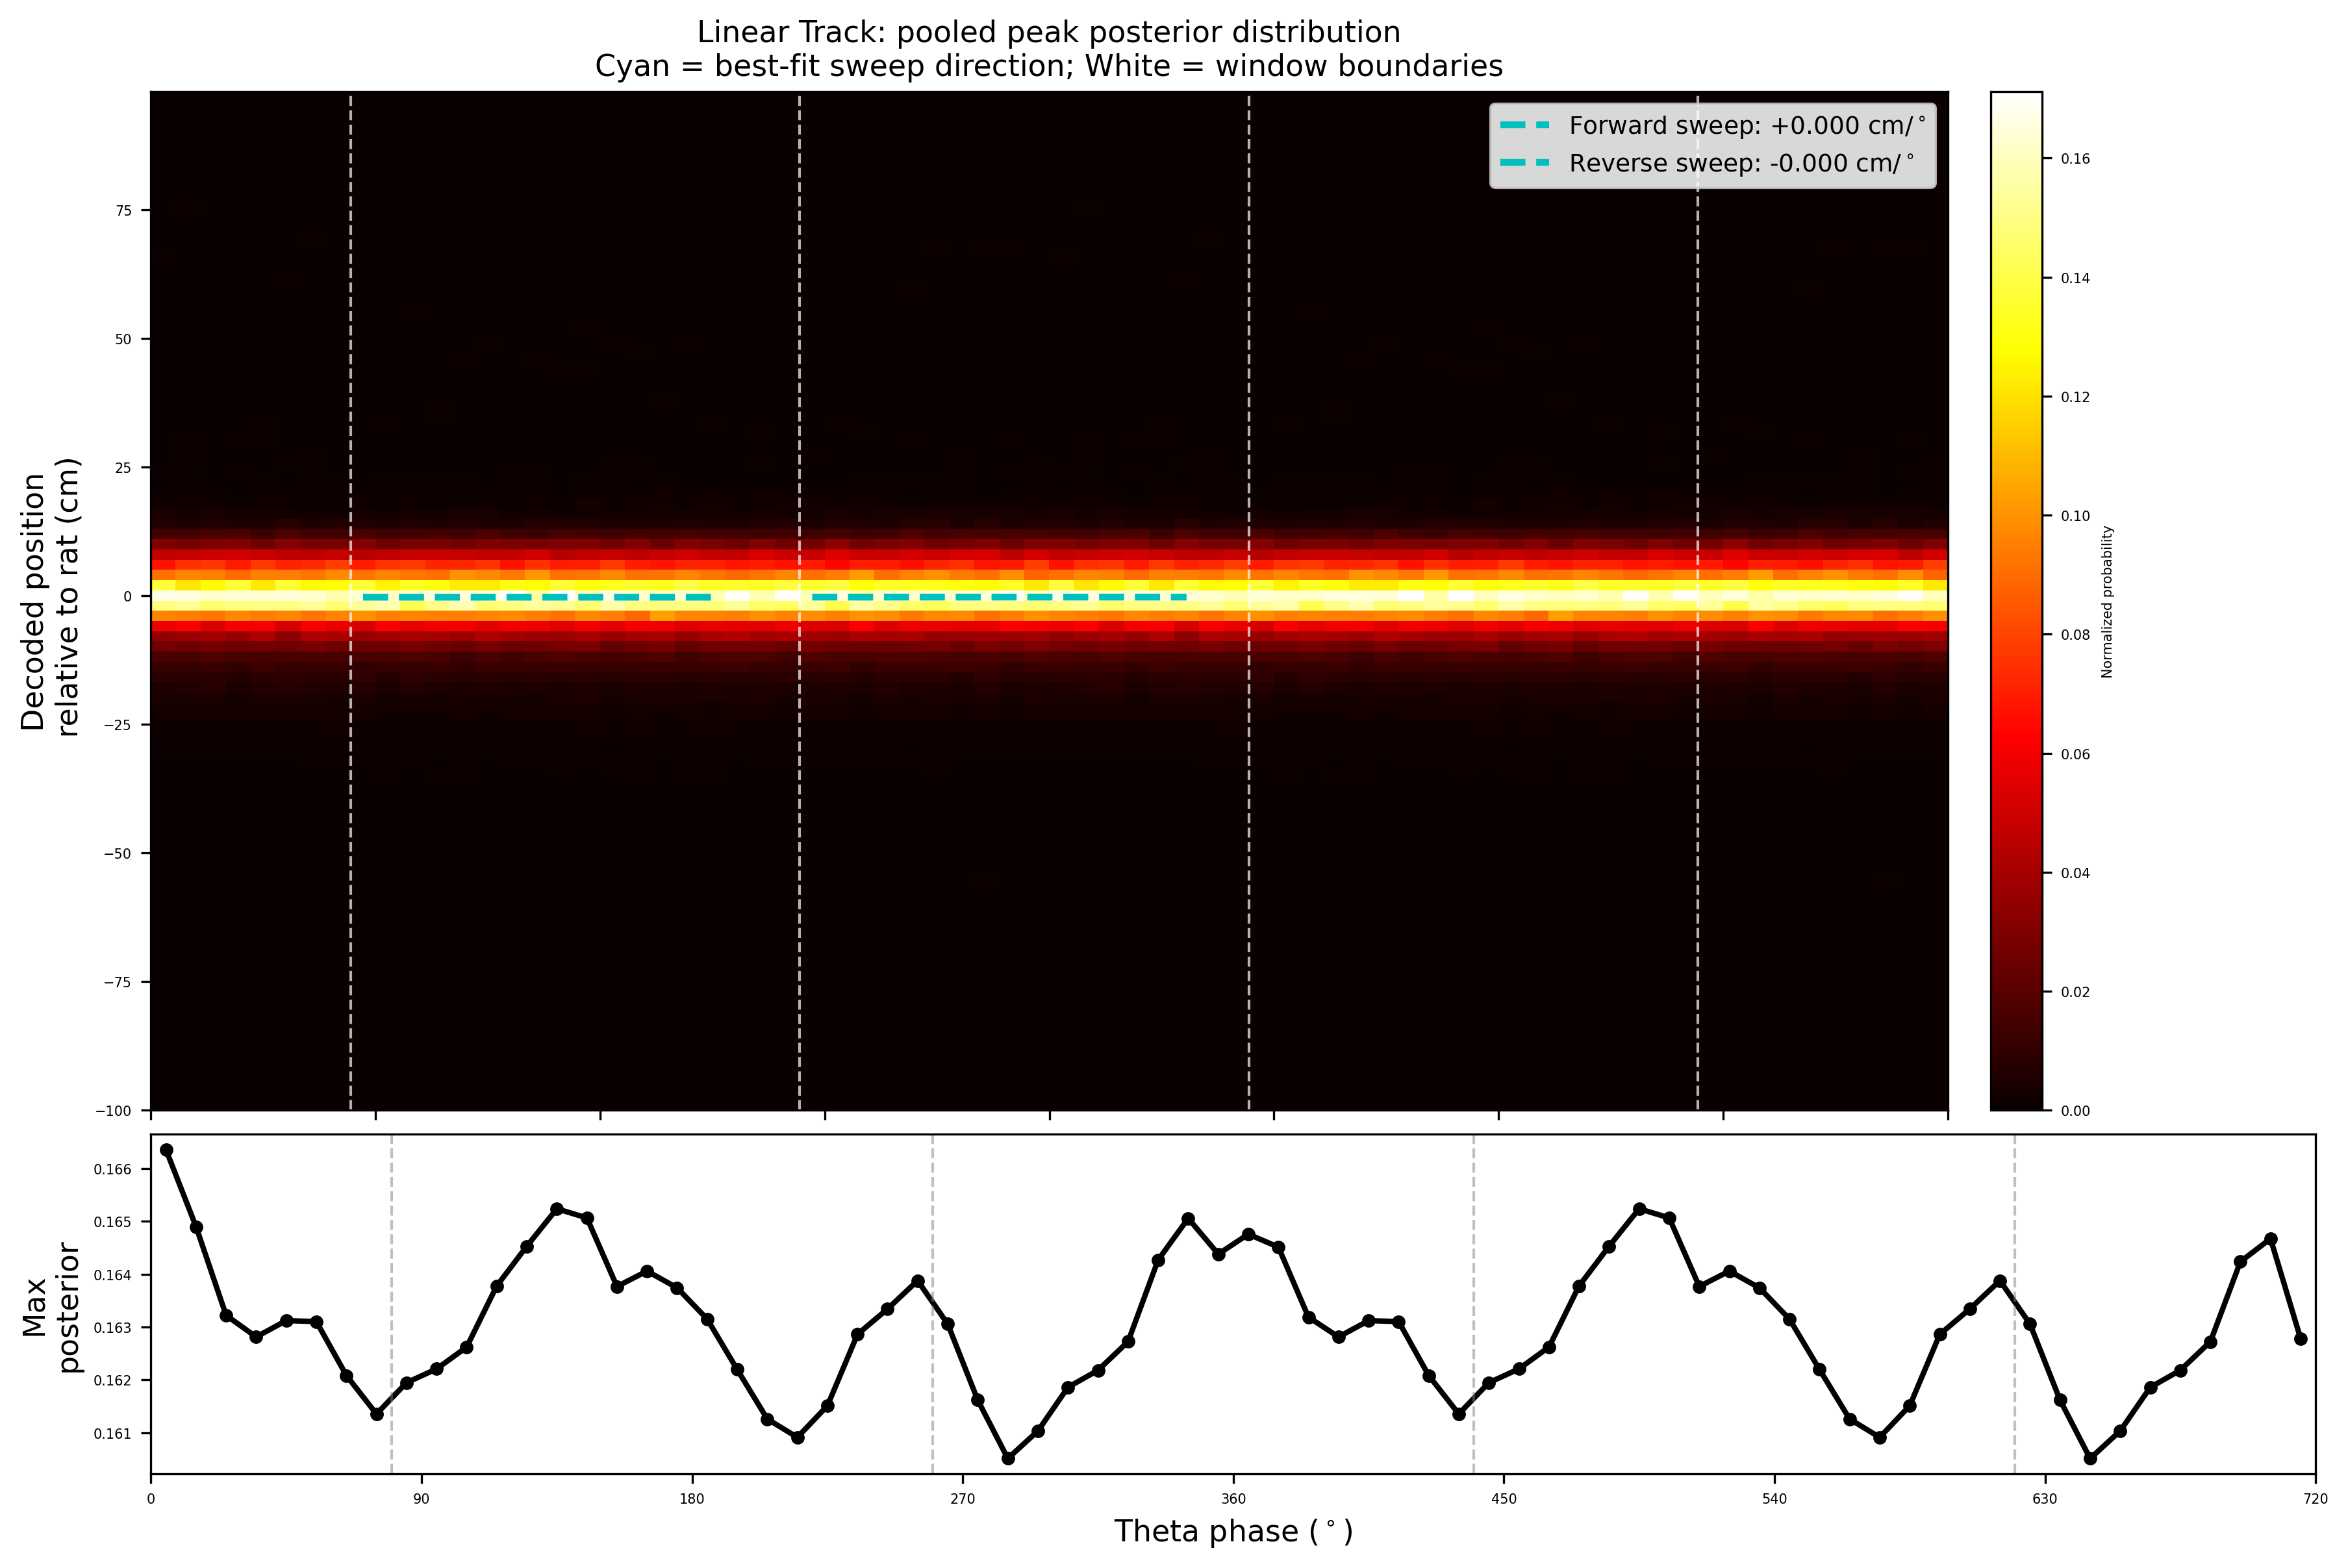

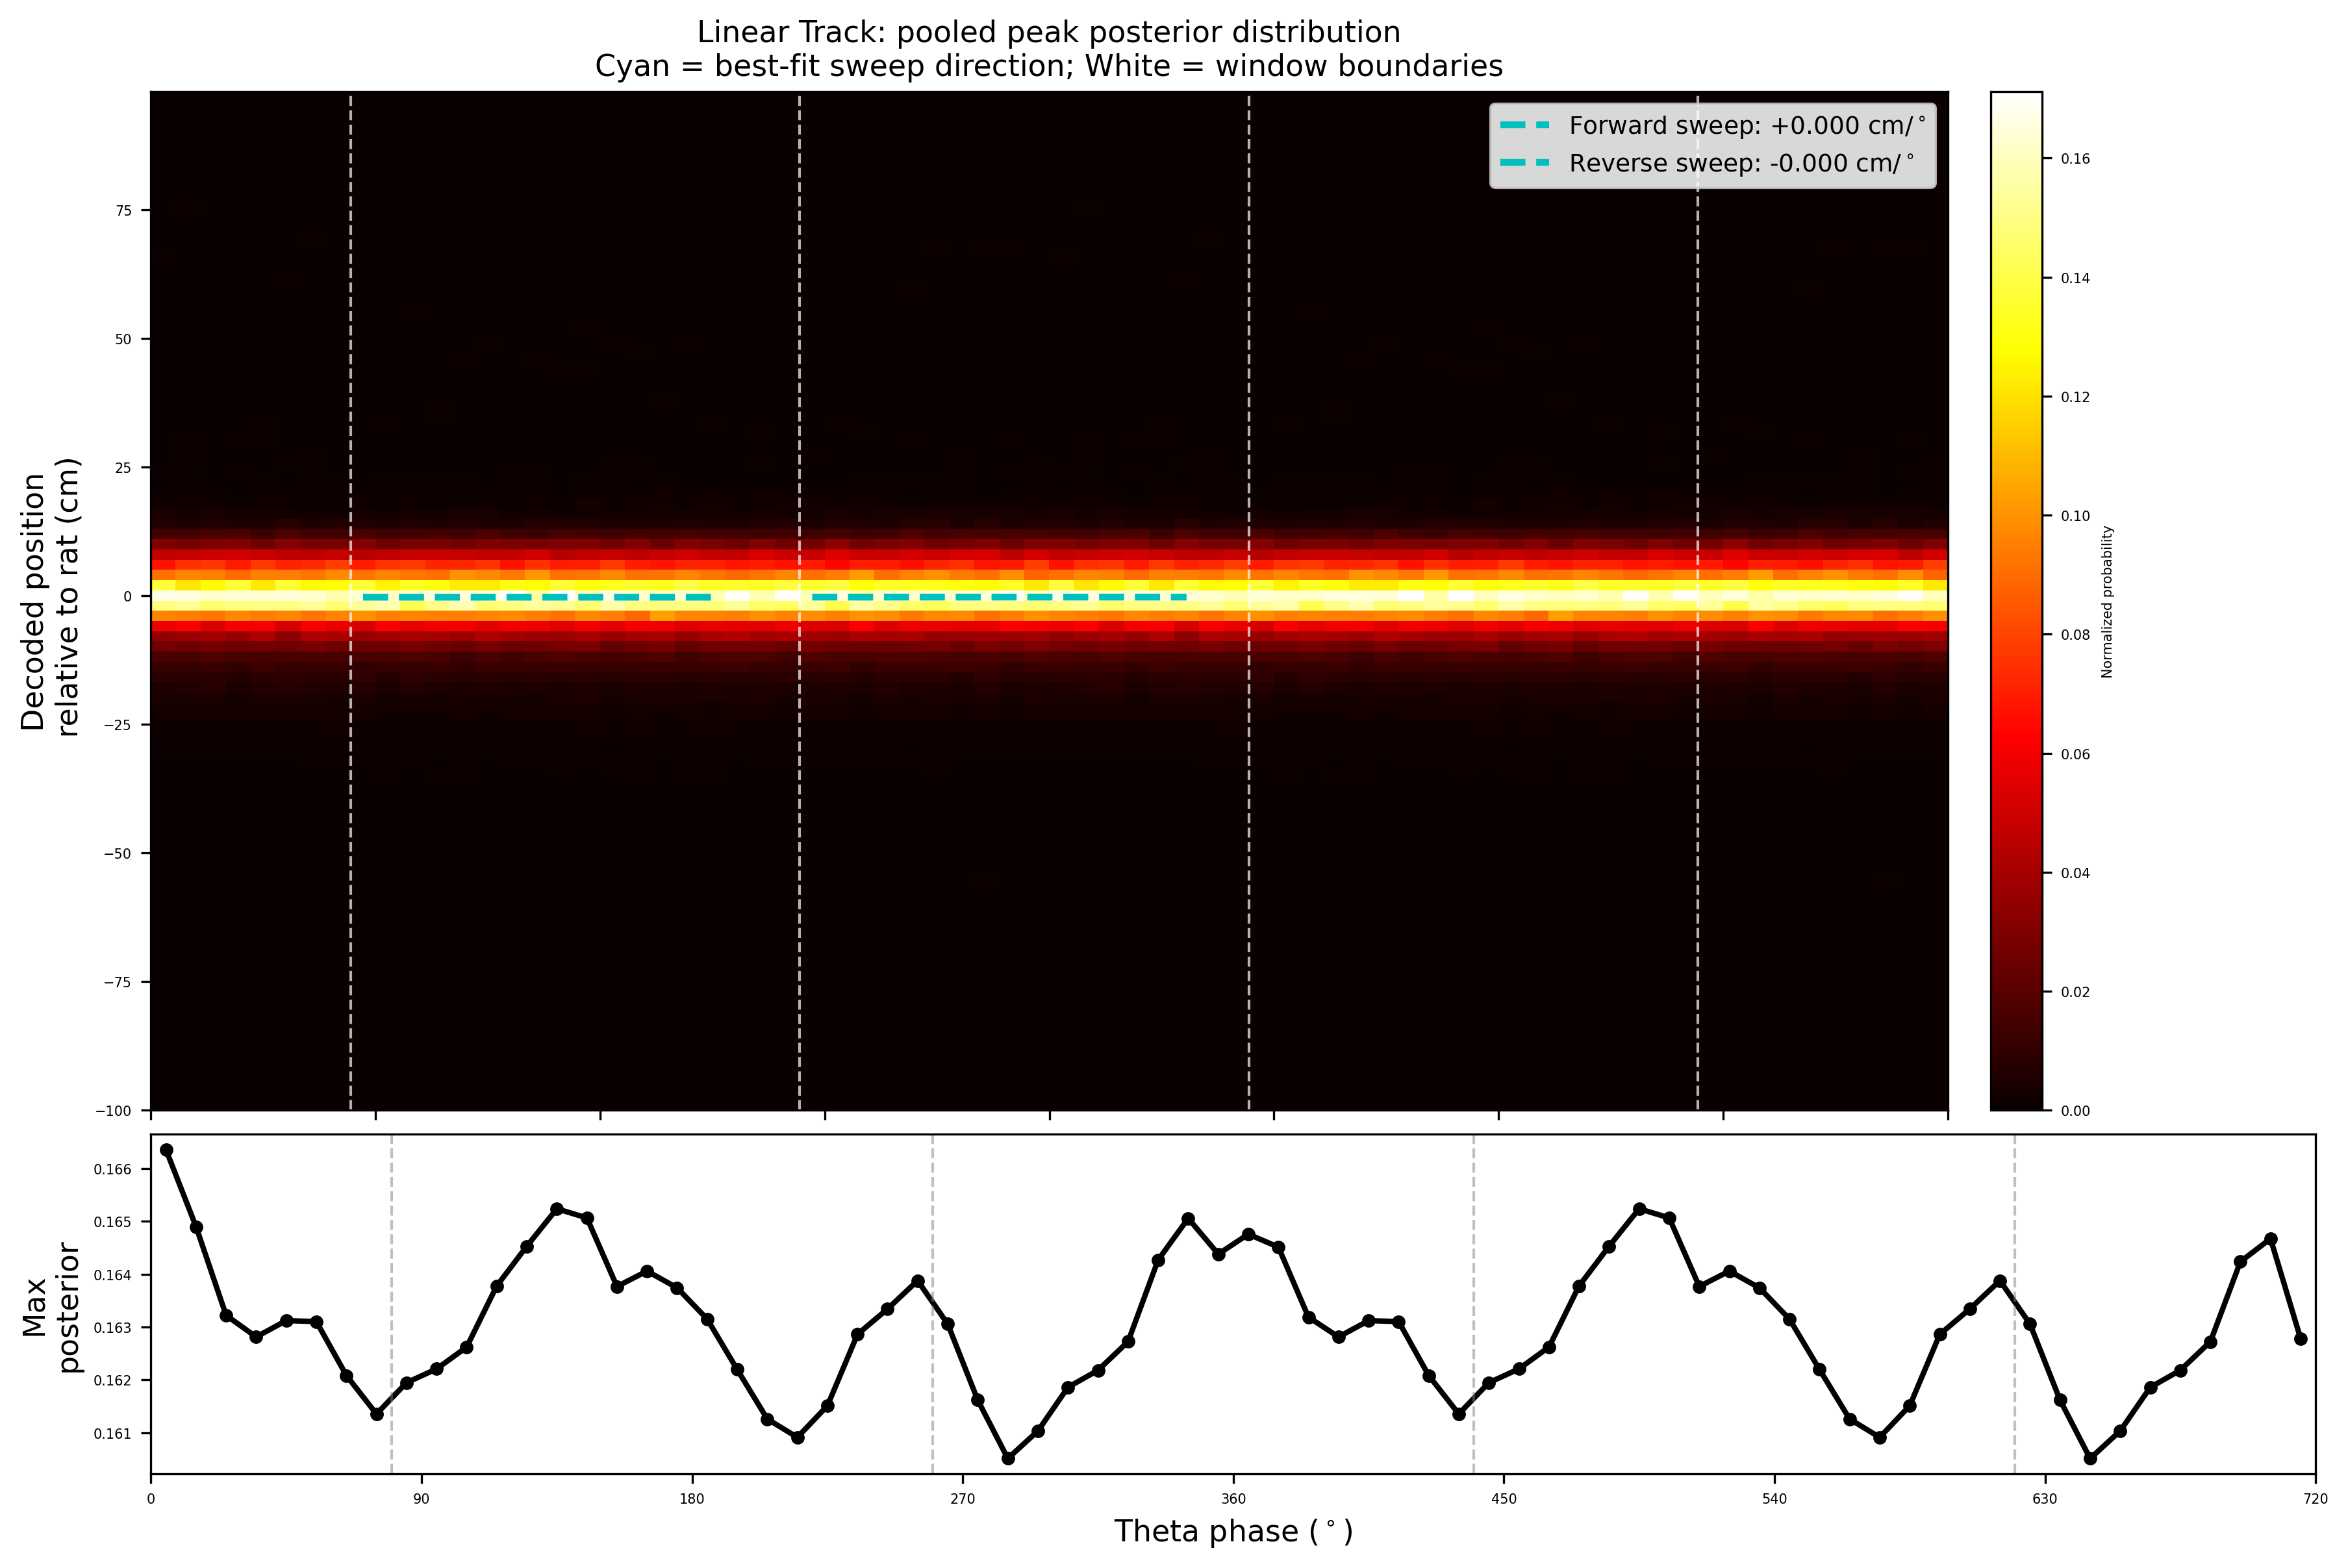

In [ ]:
#This is without running the peak posterior function
hsepl.plot_across_session_decoding_hist(
    momentum_binning_results['posterior_mass'].T
    / np.sum(momentum_binning_results['posterior_mass'].T, axis=0, keepdims=True)
)

In [ ]:
import torch
from torch.distributions import MultivariateNormal
#This is for the peak posterior function because it needs per window grids for an input
def gaussian_to_grid(means, covs, environment_size, bin_size_cm, latent_dim):
    """Turn per-window Gaussian posteriors into (T, Nx, 1) grids like emission_probabilities."""
    Z = hseu.make_ndgrid(environment_size, bin_size_cm, indexing='ij')
    out = []
    for m, c in zip(means, covs):
        m = m[:, latent_dim:].detach().double()
        c = torch.atleast_2d(c[:, latent_dim:, latent_dim:].detach().double())
        g = torch.zeros((len(m), len(Z)), dtype=torch.double)
        for t in range(len(m)):
            mvn = MultivariateNormal(m[t].ravel(), scale_tril=torch.linalg.cholesky(c[t]))
            lp = mvn.log_prob(Z)
            g[t] = torch.exp(lp - torch.logsumexp(lp, 0))
        out.append(g[:, :, None])                      # (T, Nx, 1)
    return out

In [46]:
def peak_posterior_new(emission_probabilities, environment_size, segments, spikemats, *,
                    bin_size_cm=2, phase_bin=10, minimum_max=0.01, half_width=30,
                    velocity_cutoff=10.0, spike_count_percentile=66.67,
                    count_window=(80, 240), theta_start=70.0,
                    theta_length_s=(0.08, 0.16), step_s=5e-3, direction=None):
    """Per-position peak-phase histogram (Wang et al. 2020).

    Oscillations are kept if every window is above velocity_cutoff, the cycle length is
    within theta_length_s, phase is monotonic within the cycle, and (optionally) the run
    direction matches. Of those, the top (100 - spike_count_percentile)% by spike count
    inside count_window ("firing near the peak of theta") are used.
    """
    grid = hseu.make_ndgrid(environment_size, bin_size_cm, indexing='ij').numpy()[:, 0]
    axis_col = environment_size.axes()[0]
    n_pos = 2 * half_width + 1
    dist_edges = (np.arange(n_pos + 1) - half_width - 0.5) * bin_size_cm
    n_ph = int(np.ceil(360 / phase_bin))
    #min_max = max(minimum_max, 3.0 / len(grid))
    min_max = minimum_max

    rel, phase_all, osc_all, vel_all, spk_all, dir_all, t_all = [], [], [], [], [], [], []
    osc_offset = 0
    for ep, frame, spk in zip(emission_probabilities, segments, spikemats):
        ep = ep.detach().numpy().reshape(len(ep), -1)
        pos = frame[axis_col].values
        d = np.sign(pos[-1] - pos[0]) or 1.0
        R = np.zeros((n_pos, len(ep)))
        for t in range(len(ep)):
            dbin = np.digitize((grid - pos[t]) * d, dist_edges) - 1
            ok = (dbin >= 0) & (dbin < n_pos)
            np.add.at(R[:, t], dbin[ok], ep[t][ok])
        rel.append(R)
        ph = np.mod(frame['Phase Deg'].values, 360.0); ph[ph == 0] = 360.0
        phase_all.append(ph)
        osc_all.append(frame['Oscillation Number'].values.astype(int) + osc_offset)
        osc_offset = osc_all[-1].max() + 1
        vel_all.append(frame['Velocity'].values)
        spk_all.append(np.asarray(spk).sum(axis=1))
        dir_all.append(np.full(len(ep), d))
        t_all.append(frame.index.values)
    R = np.concatenate(rel, axis=1); phase = np.concatenate(phase_all); osc = np.concatenate(osc_all)
    vel = np.concatenate(vel_all); spk = np.concatenate(spk_all); dirs = np.concatenate(dir_all)
    t_all = np.concatenate(t_all)

    lo, hi = count_window
    def in_window(ph):
        return (ph > lo) & (ph <= hi) if lo < hi else (ph > lo) | (ph <= hi)

    info = {}
    for o in np.unique(osc):
        m = np.flatnonzero(osc == o)
        if len(m) < 2 or np.any(vel[m] < velocity_cutoff):
            continue
        if direction is not None and dirs[m[0]] != direction:
            continue
        dur = t_all[m[-1]] - t_all[m[0]] + step_s
        if not (theta_length_s[0] <= dur <= theta_length_s[1]):
            continue
        ph = phase[m].copy(); ph[ph <= theta_start] += 360.0
        if np.any(np.diff(ph) < 0):
            continue
        info[o] = spk[m][in_window(phase[m])].sum()

    counts = np.array(list(info.values()))
    thr = np.percentile(counts, spike_count_percentile) if len(counts) else np.inf
    selected = [o for o, s in info.items() if s >= thr]
    print(f"{len(info)} oscillations pass flags; {len(selected)} selected "
        f"(>= {thr:.0f} spikes in {count_window})")

    dist_of_peak = np.zeros((n_pos, n_ph))
    for o in selected:
        m = (osc == o) & (spk > 0)  #makes sure each window has spikes
        if m.sum() < 2:
            continue
        cur, ph = R[:, m], phase[m]  #cycles throuugh the relative posterior, positioned by window
        mx = cur.max(axis=1)   #for each position row, what is the highest probability that position reached at any point in the cycle
        for p in range(n_pos):  #this looks for when the max probability is reached for phase p
            #mx[p] >= min_max drops rows that don't carry high probability
            # np.all... drops rows with constant probability across entire cycle
            if mx[p] >= min_max and not np.all(cur[p] == mx[p]):  #this is the phase it reached max
                for phv in ph[cur[p] == mx[p]]:
                    dist_of_peak[p, np.clip(int(np.ceil(phv / phase_bin)) - 1, 0, n_ph - 1)] += 1  #translates phase to bin indexing
    col = dist_of_peak.sum(axis=0, keepdims=True); col[col == 0] = 1
    return {"dist_of_peak_post": dist_of_peak, "norm_dist": dist_of_peak / col,
            "n_oscillations_used": len(selected), "spike_count_threshold": thr}
    
    


In [ ]:
from scipy.signal import find_peaks
from scipy.ndimage import gaussian_filter1d

def _two_troughs(trace, phase_bin, smooth_sigma=1.0):
    n = len(trace)
    x = np.concatenate([trace, trace, trace])
    if smooth_sigma:
        x = gaussian_filter1d(x, smooth_sigma)
    idx, _ = find_peaks(-x)
    idx = np.unique(idx[(idx >= n) & (idx < 2 * n)] - n)
    j0 = idx[np.argmin(x[idx + n])]  # deepest local minimum
    if len(idx) == 1:
        j1 = (j0 + n // 2) % n
    else:
        other = idx[idx != j0]
        sep = np.abs(((other - j0 + n // 2) % n) - n // 2) * phase_bin
        j1 = other[np.argmin(np.abs(sep - 180.0))]   # the one nearest opposite
    return np.sort([j0, j1]) * phase_bin + phase_bin / 2

def identify_theta_sequence_windows(bimodal_firing_rate, decoding_distribution, phase_bin=10):
    fr_t  = _two_troughs(np.asarray(bimodal_firing_rate), phase_bin, smooth_sigma=1.0)
    dec_t = _two_troughs(np.asarray(decoding_distribution).max(axis=0), phase_bin, smooth_sigma=1.0)
    w = lambda a, b: [a % 360, b % 360]
    return {
        'major_peak_window': w(fr_t[1] + phase_bin,  fr_t[0] - phase_bin),
        'minor_peak_window': w(fr_t[0],              fr_t[1]),
        'forward_window':    w(dec_t[1] + phase_bin, dec_t[0] - phase_bin),
        'reverse_window':    w(dec_t[0] + phase_bin, dec_t[1] - phase_bin),
        'firing_rate_troughs_deg': fr_t.tolist(),
        'decoding_troughs_deg':    dec_t.tolist(),
    }

In [41]:
total_duration = raw_data.raw_position.time_support.tot_length('s')

firing_rate_per_phase, phase_centers = hsea.calculate_phase_locking(
    theta_data.spikes_with_phase,
    total_duration,
    10.0,                       
    phase_bin_size_deg=10,
)
modality_results = hsea.classify_theta_modality(
    firing_rate_per_phase,
    theta_data.spikes_with_phase,
)
population_stats = hsea.calculate_population_firing_rates(
    firing_rate_per_phase,
    modality_results,
    raw_data.excitatory_neurons,
)

bimodal_fr = population_stats['bimodal']['smooth_rate'][0]
print(bimodal_fr.shape, population_stats['bimodal']['n_cells'])

(36,) 26


2330 oscillations pass flags; 801 selected (>= 56 spikes in (80, 240))
1166 oscillations pass flags; 396 selected (>= 59 spikes in (80, 240))
1164 oscillations pass flags; 407 selected (>= 53 spikes in (80, 240))
[75.0, 255.0] [np.float64(265.0), np.float64(65.0)] [np.float64(85.0), np.float64(245.0)]
both 801
pos 396
neg 407


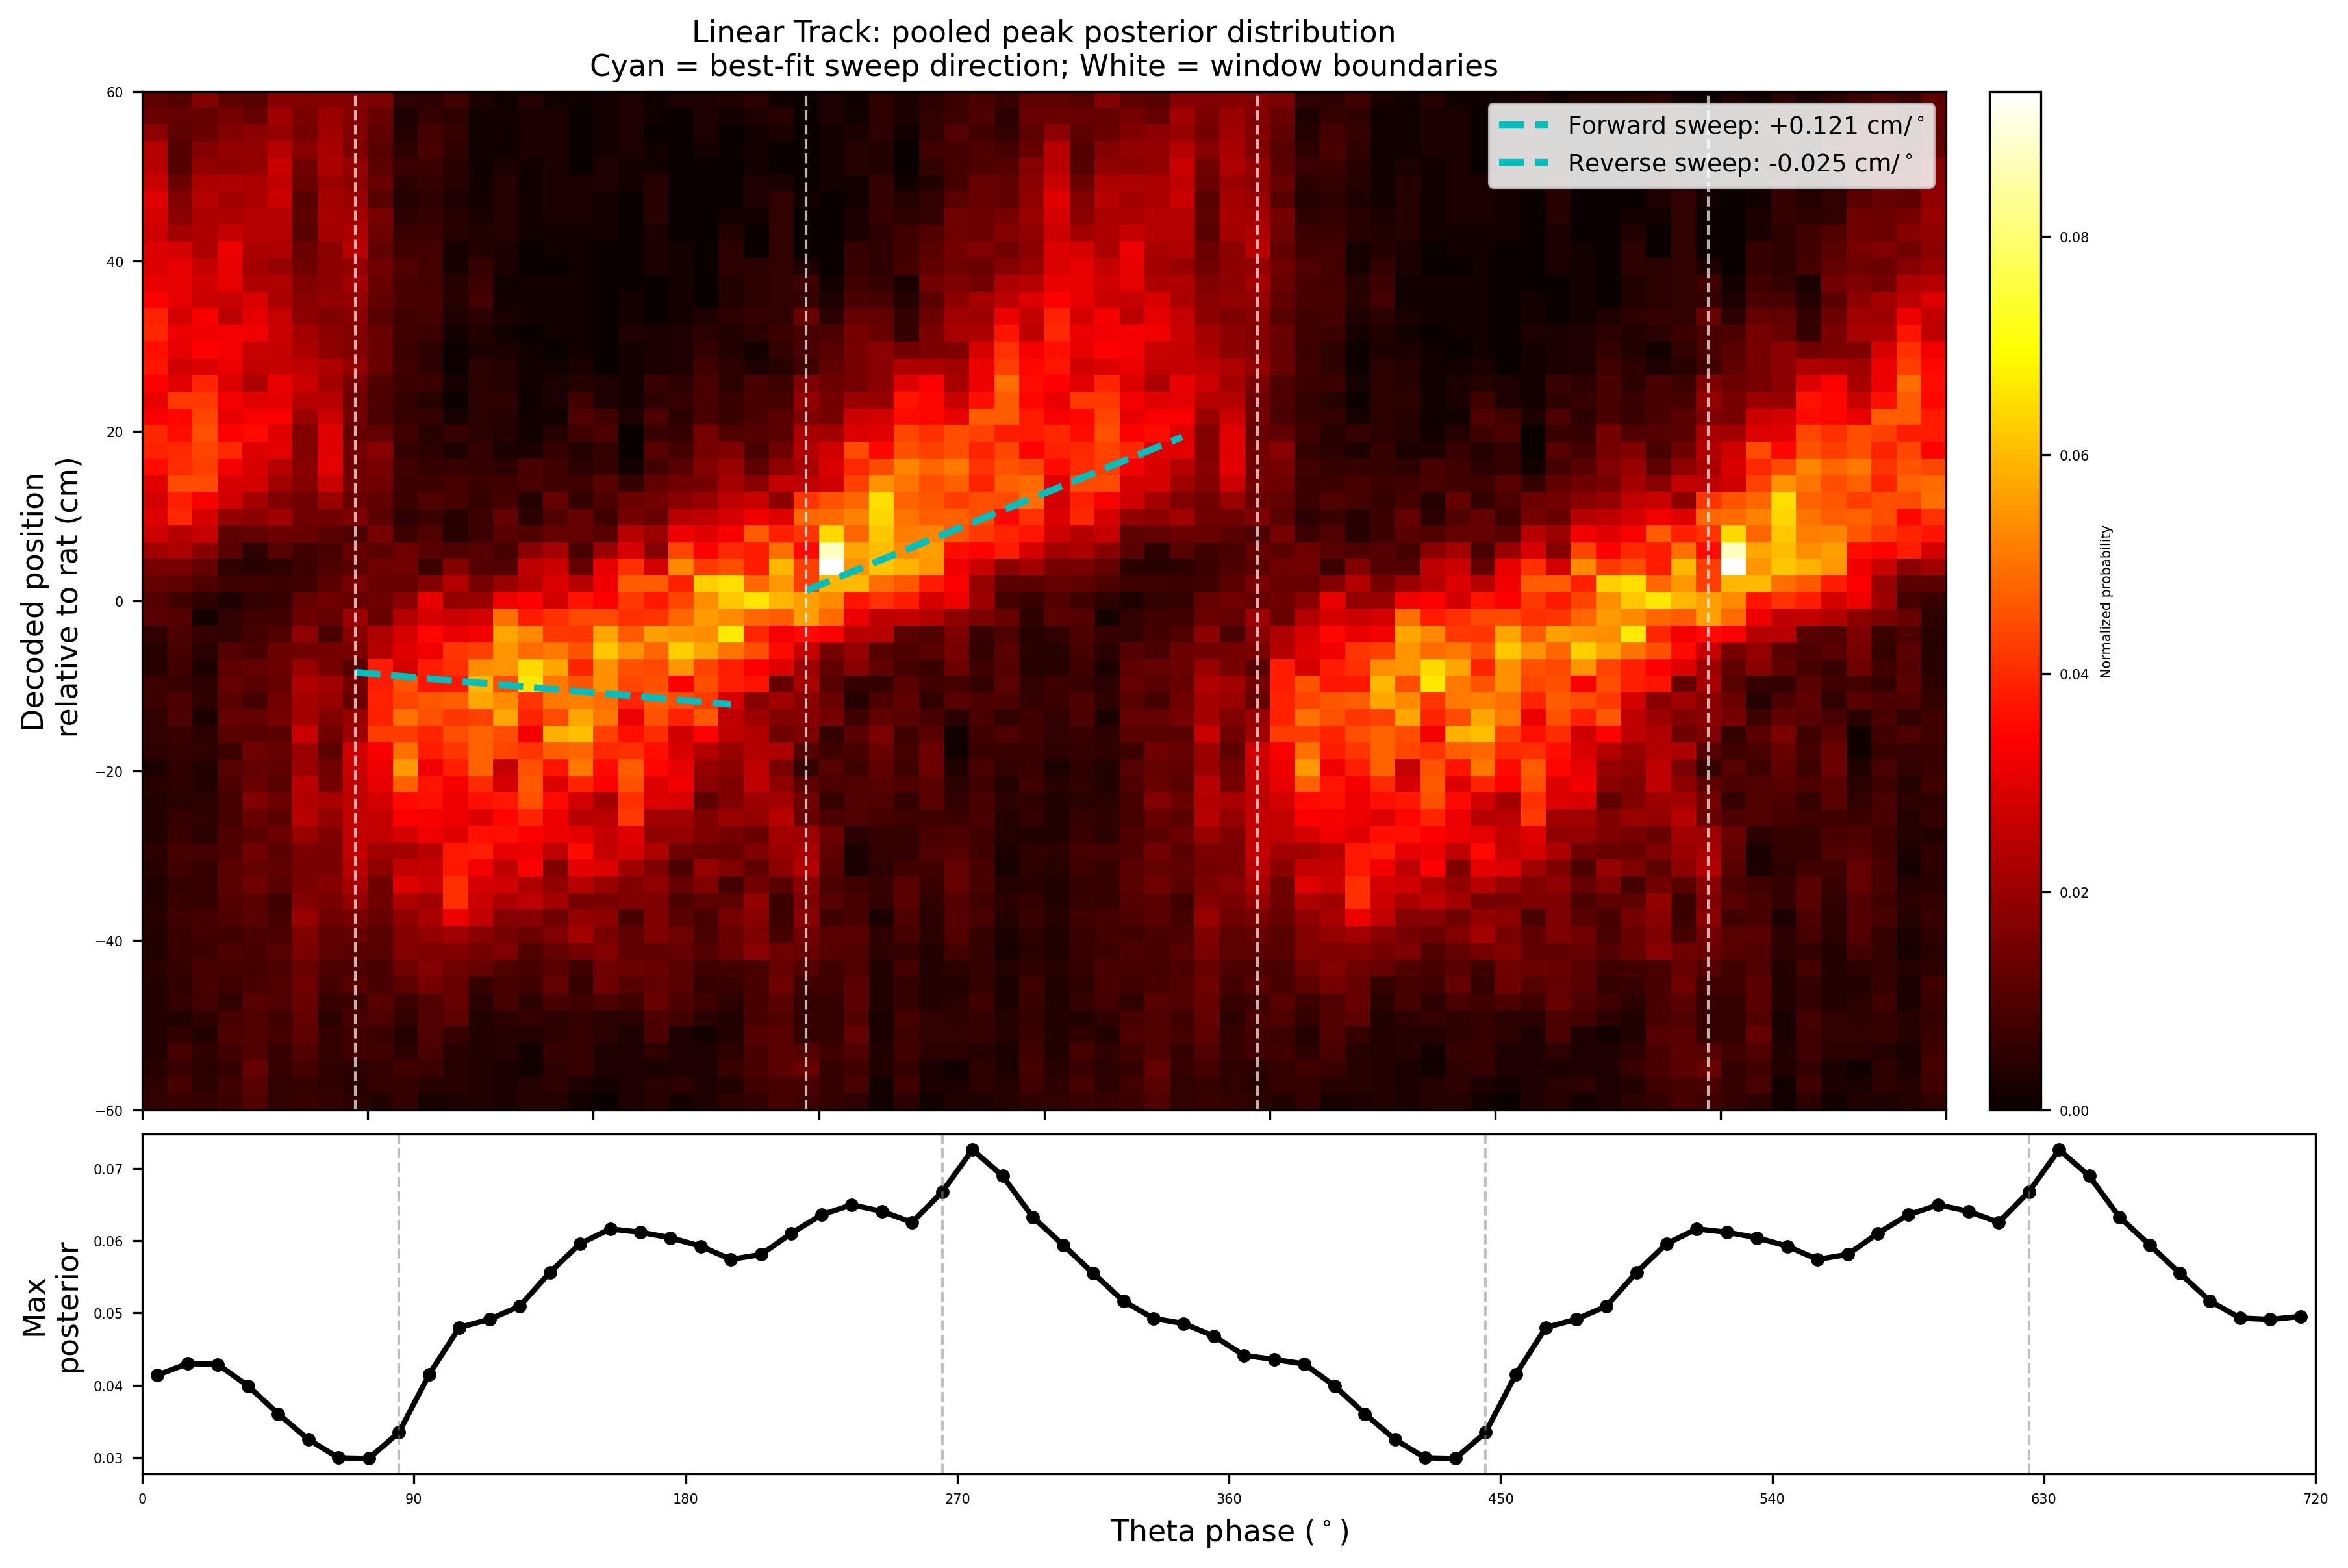

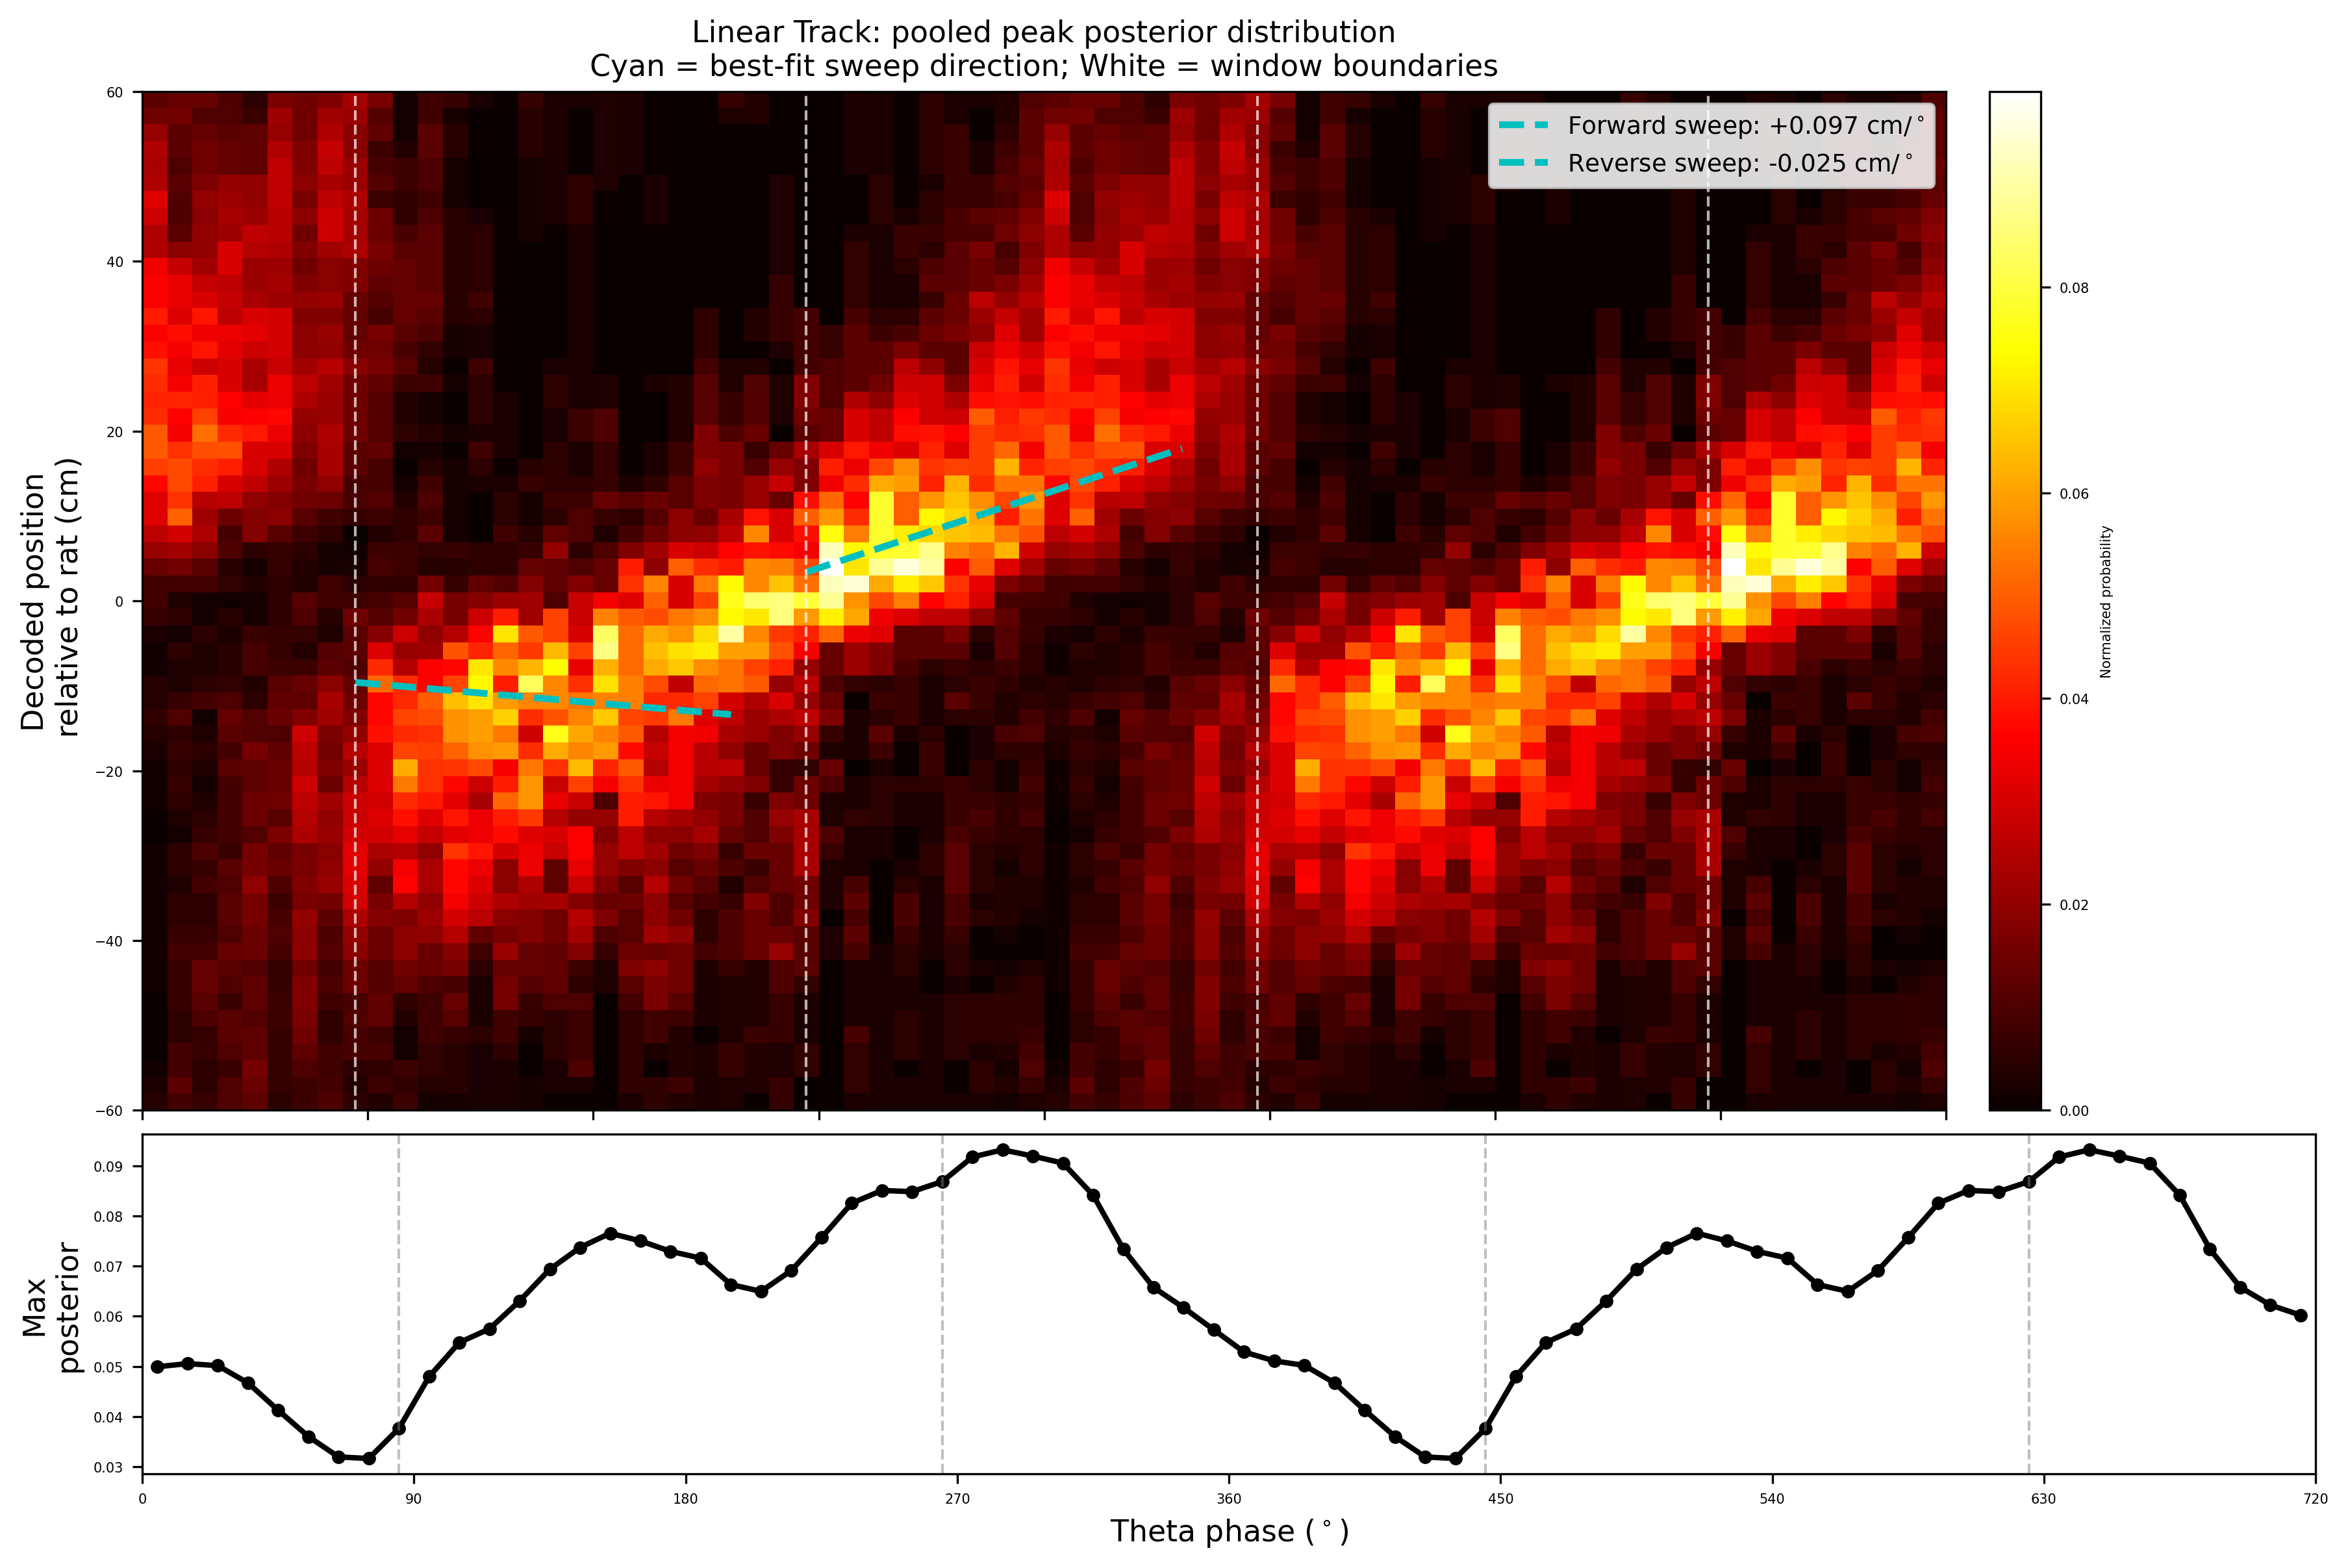

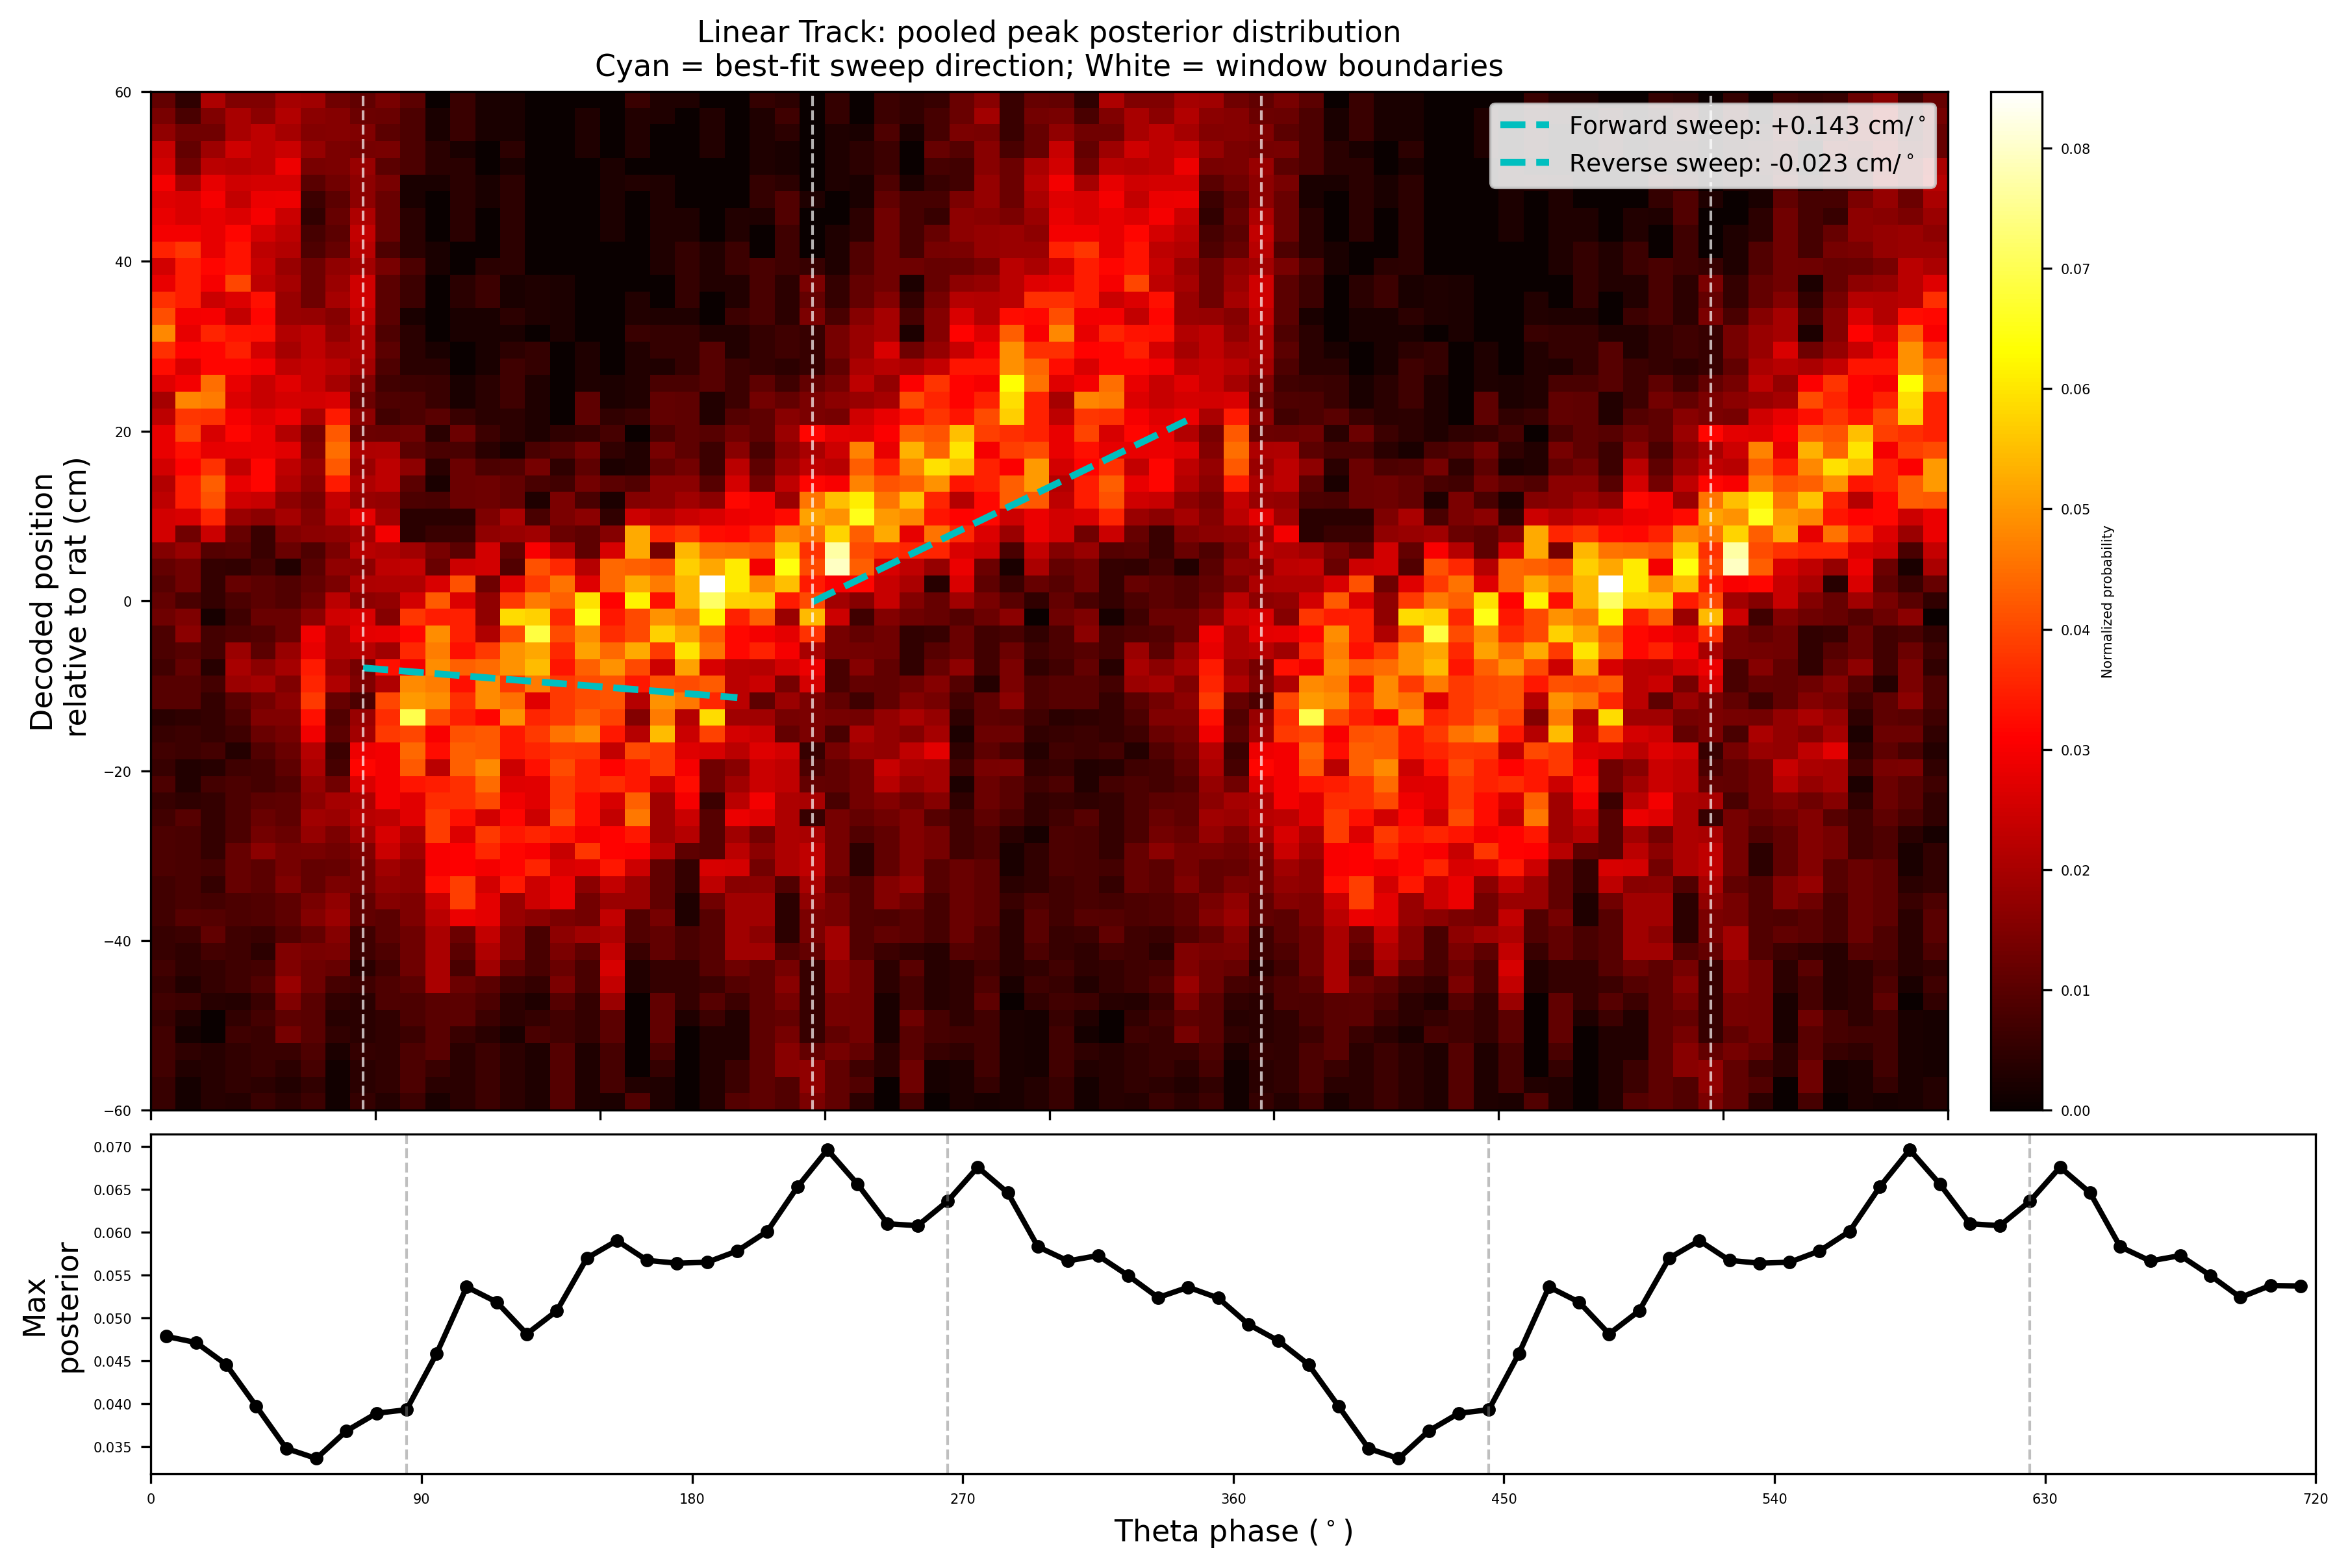

In [ ]:
###Both does not filter theta phases by direction animal is running
### Pos runs are when animal is running up the track, neg is opposite direcition
# the distribution from peak_posterior_new for the naive bayesian decoding

results = {name: peak_posterior_new(momentum.emission_probabilities, raw_data.environment_size,
                                theta_data.ground_truth, theta_data.spikes, direction=dr)
            for name, dr in (("both", None), ("pos", 1.0), ("neg", -1.0))}

bimodal_fr = population_stats['bimodal']['smooth_rate'][0]
#This is an old function (defined in previous cell) to calculate the forward and reverse window but it isn't very good at the moment 
win = identify_theta_sequence_windows(bimodal_fr, results["both"]['norm_dist'], phase_bin=10)
print(win['decoding_troughs_deg'], win['forward_window'], win['reverse_window'])

for name, r in results.items():
    print(name, r['n_oscillations_used'])
    hsepl.plot_across_session_decoding_hist(r['norm_dist'],
                                            forward_window=tuple(win['forward_window']),
                                            reverse_window=tuple(win['reverse_window']))

2330 oscillations pass flags; 801 selected (>= 56 spikes in (80, 240))
lambda: 19.999999999999996 v_std: 150.00000000000009
oscillations used: 801


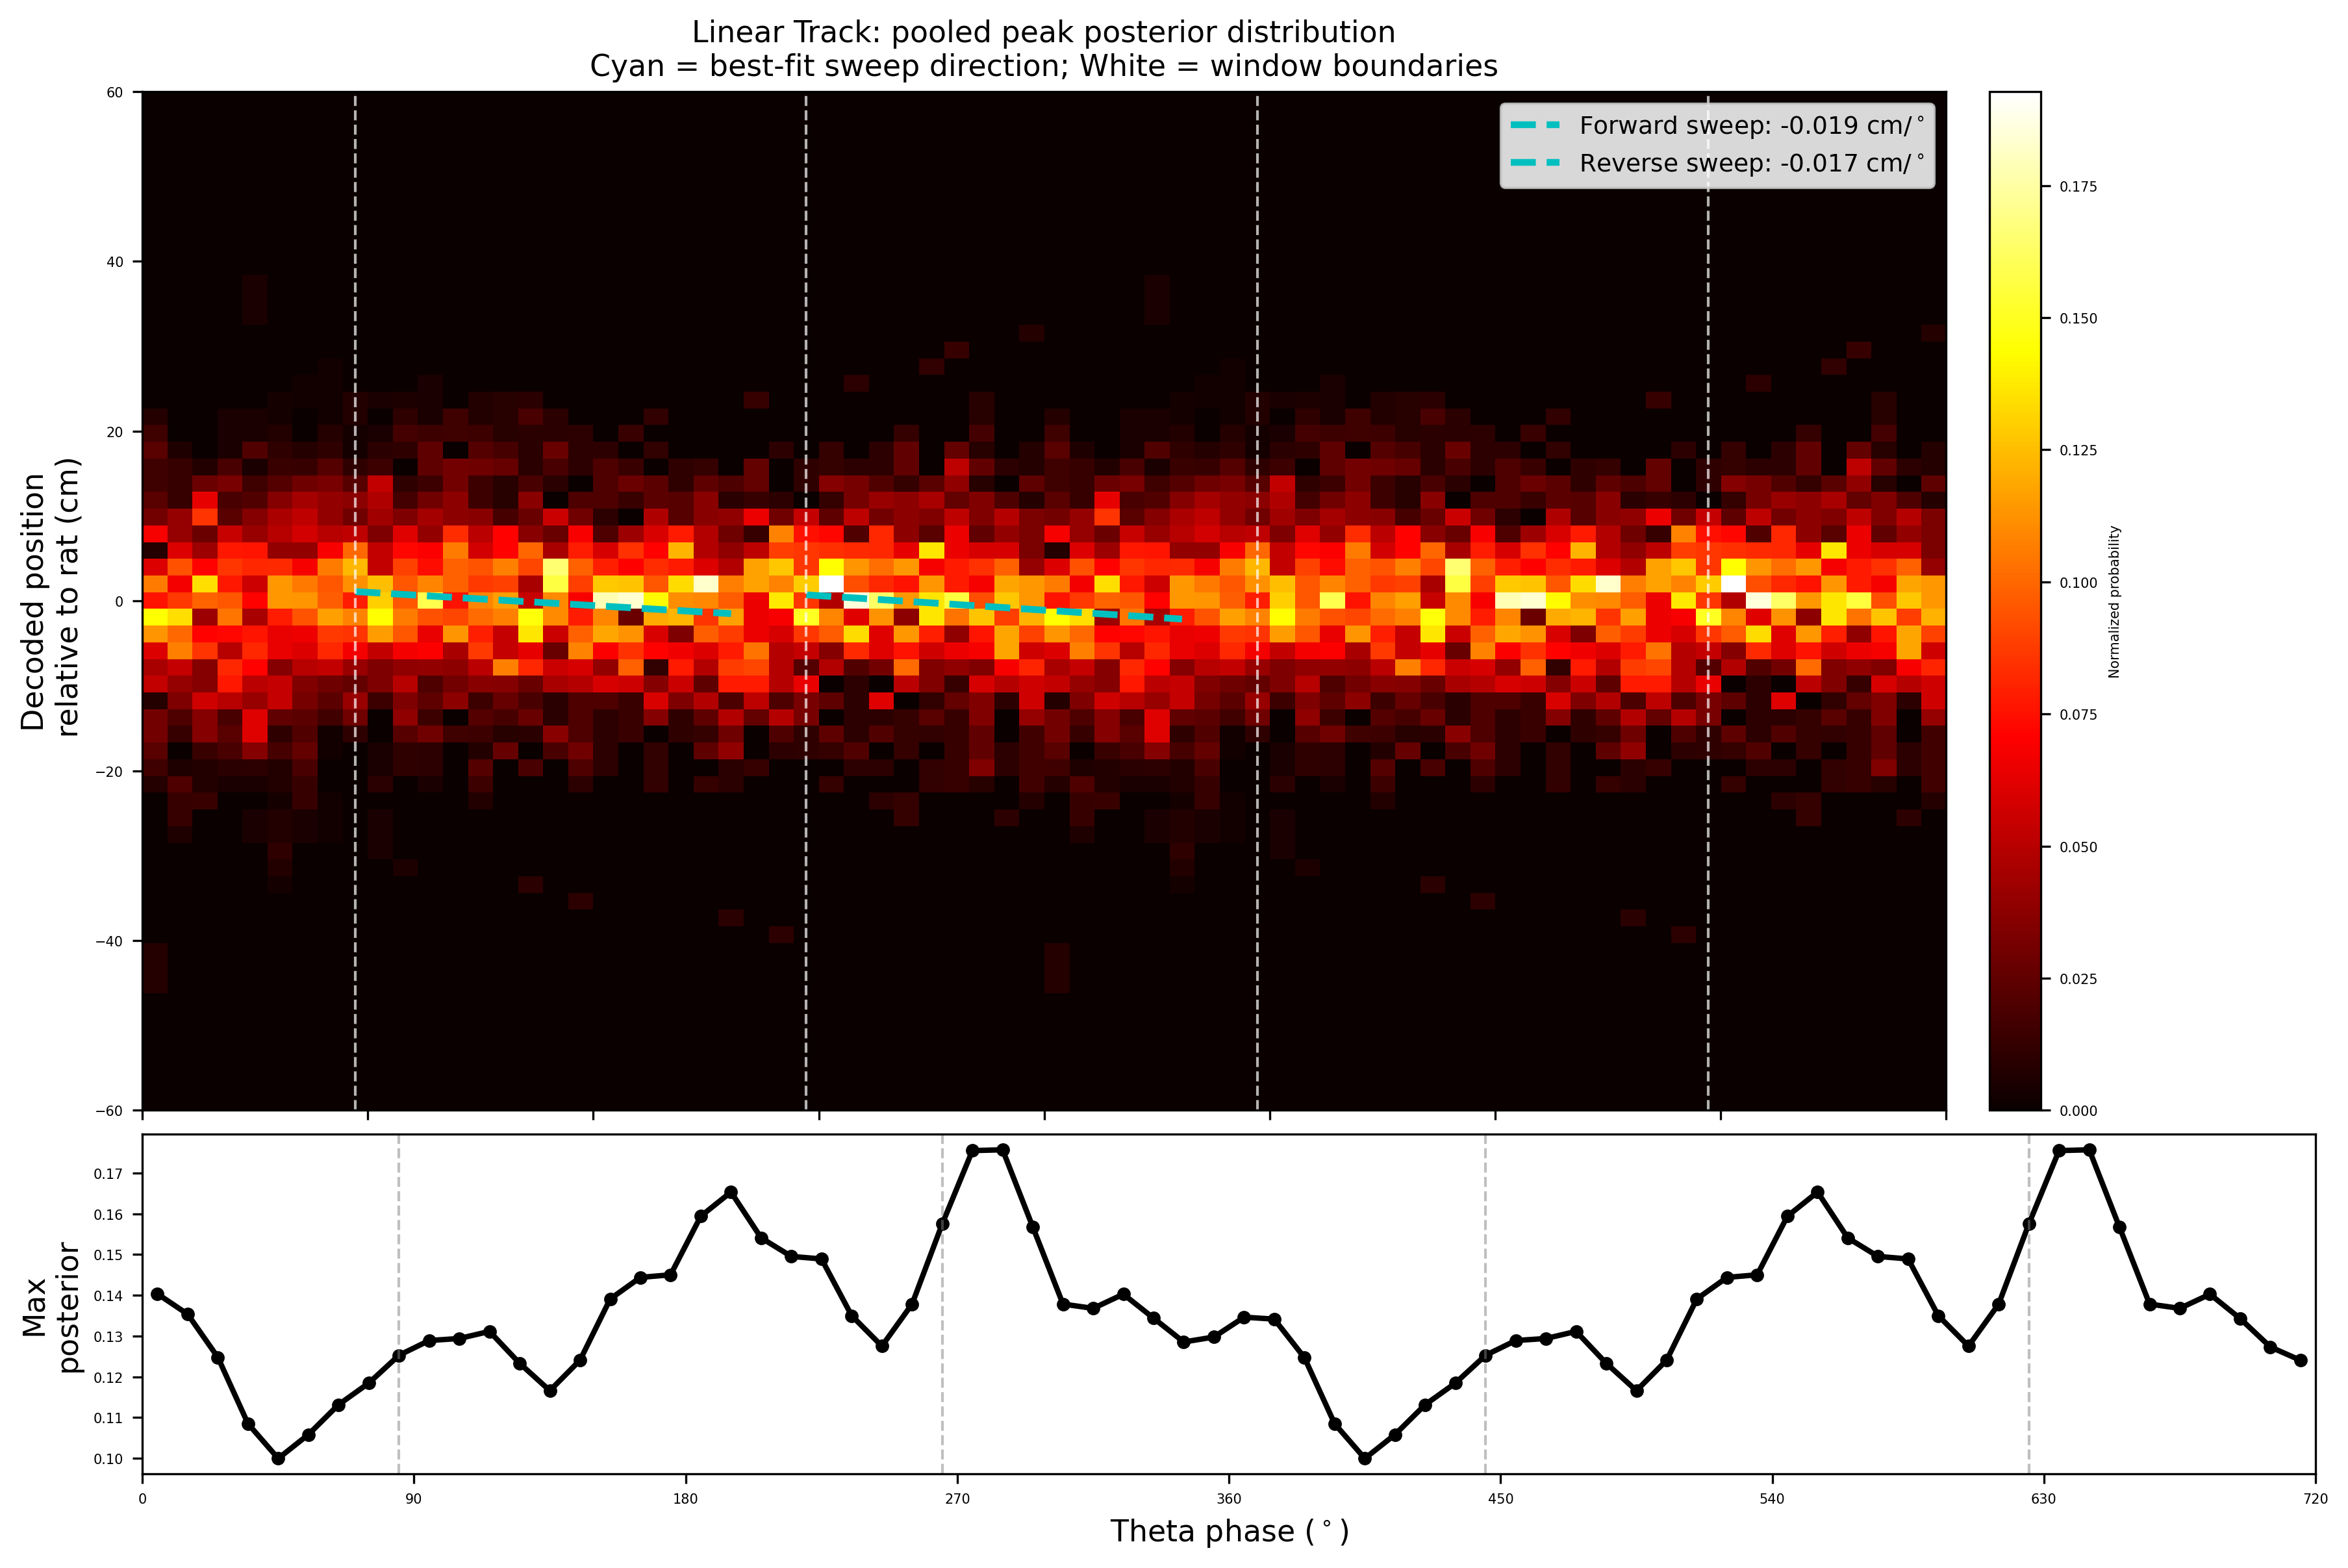

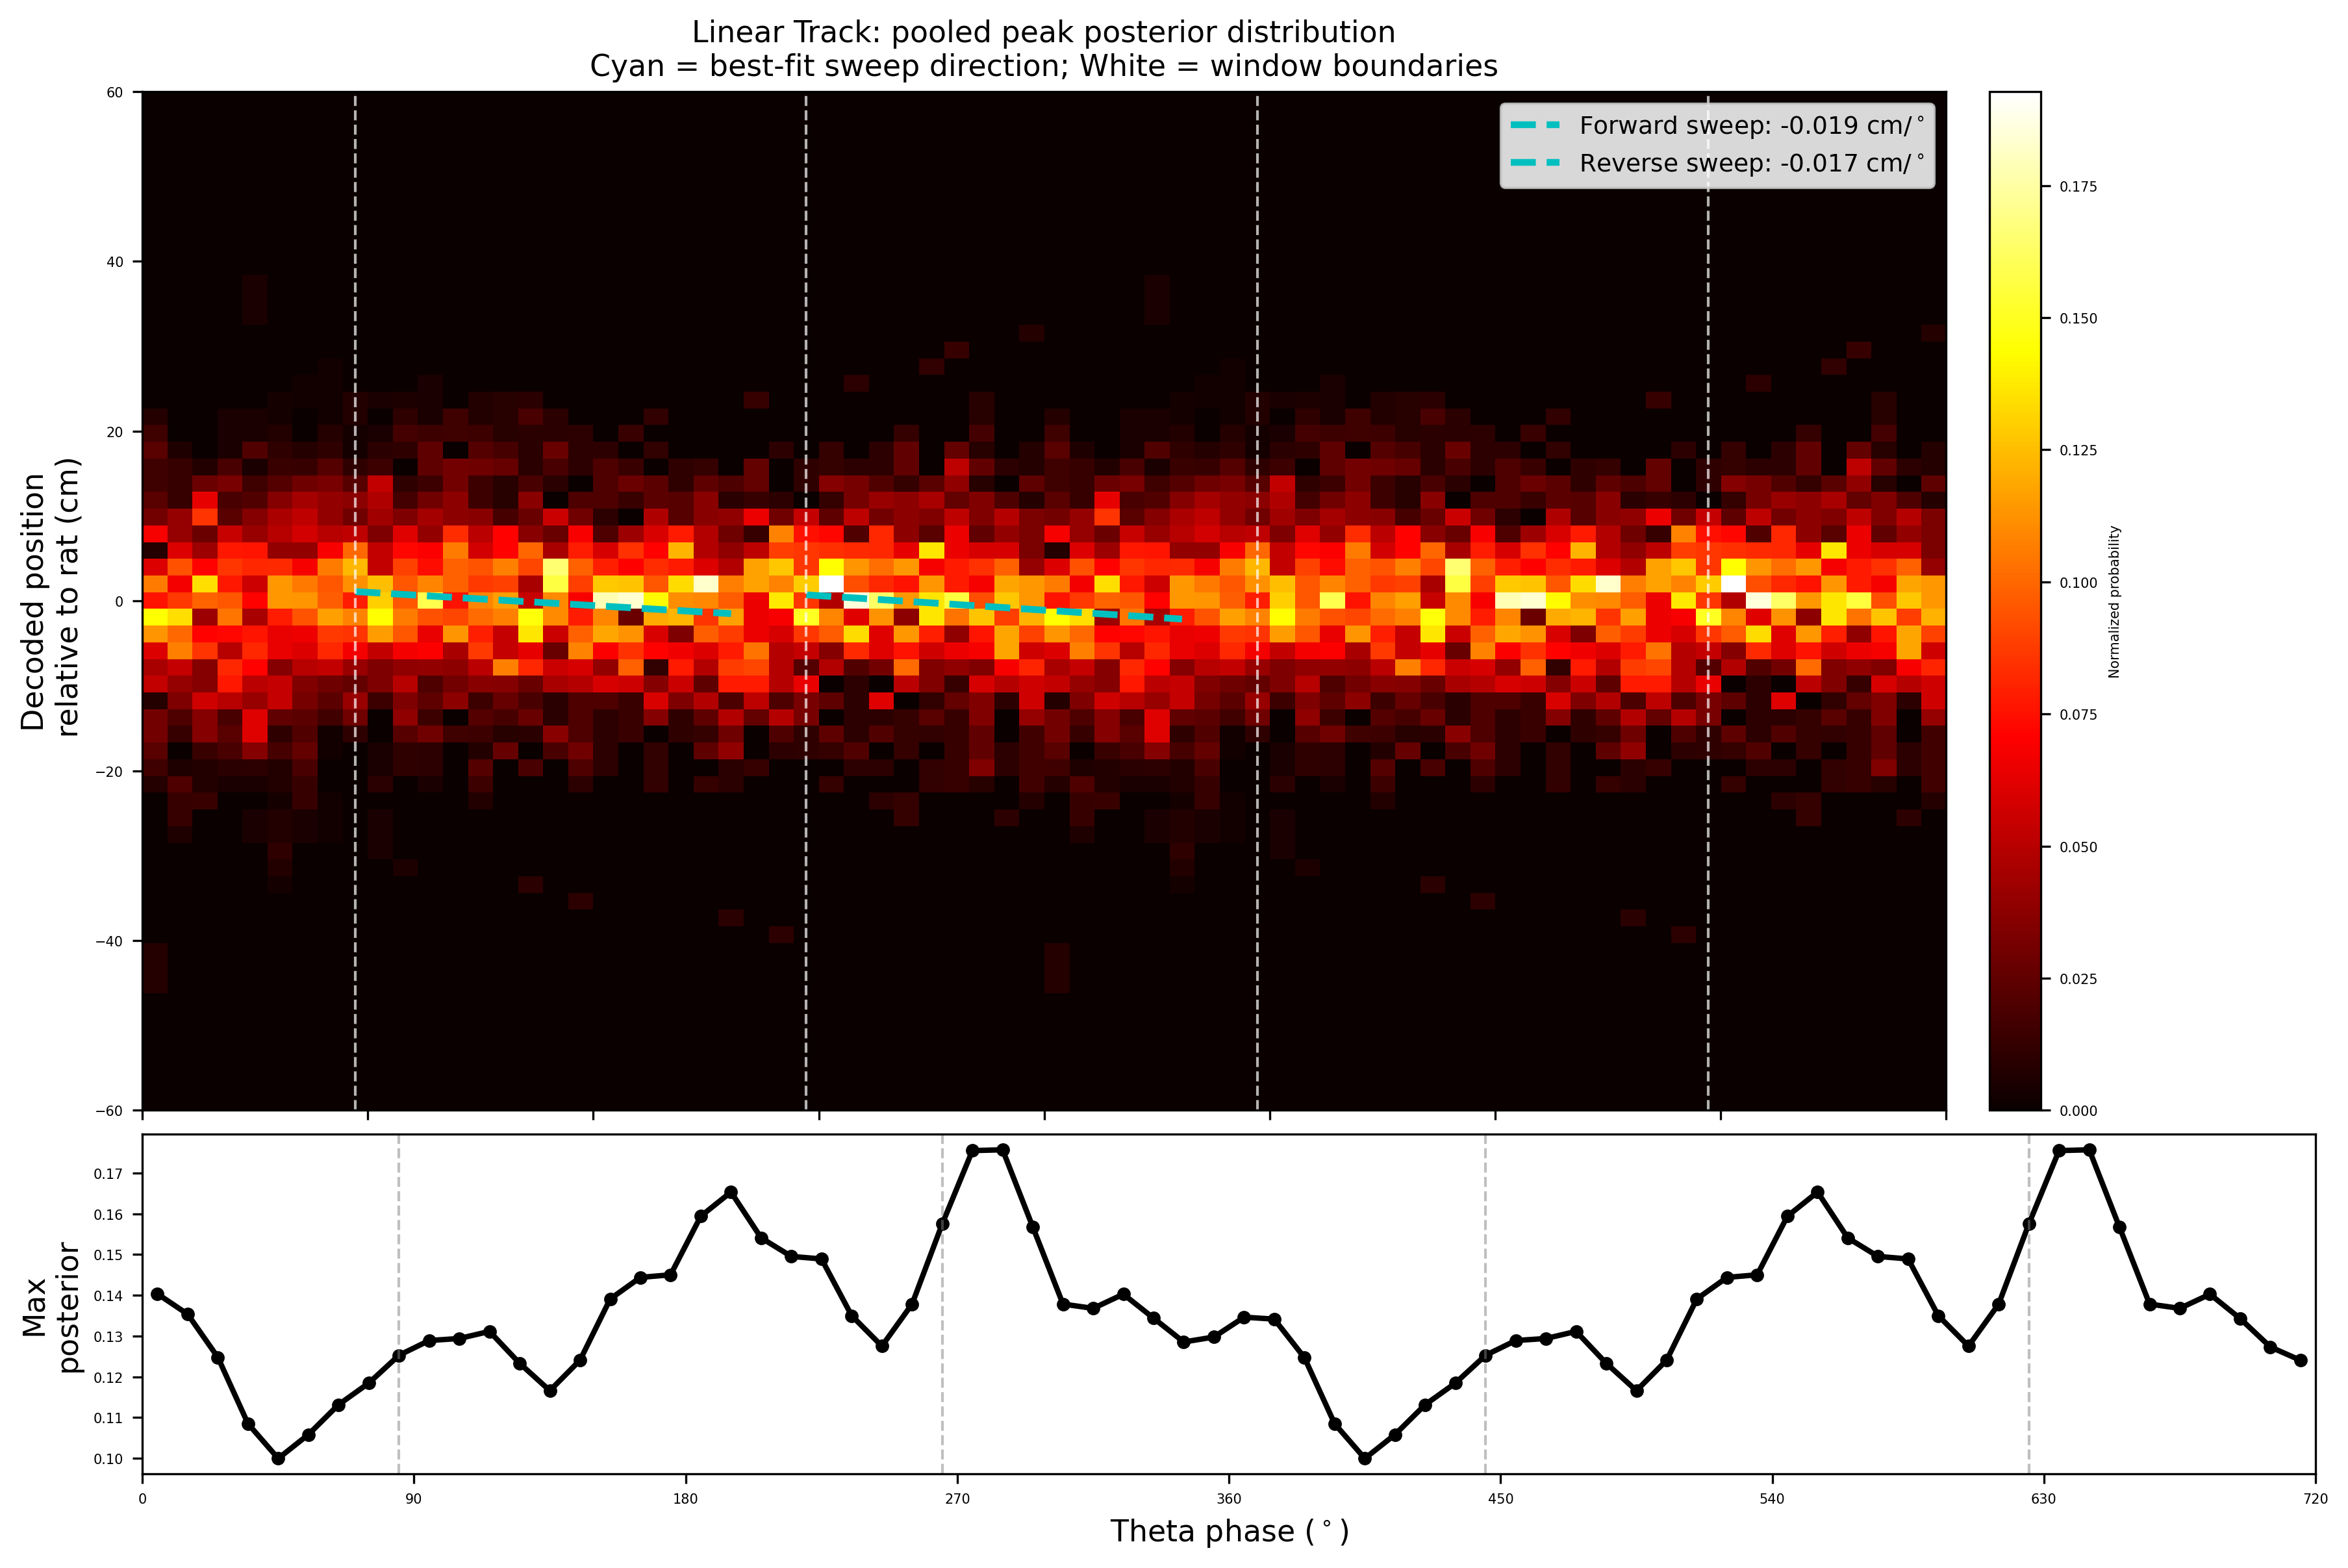

In [49]:
# EM-fitted dynamics 
em_grids = gaussian_to_grid(momentum_results.smoothed_mean, momentum_results.smoothed_cov,
                              raw_data.environment_size, bin_size, momentum.latent_dim)

r_em = peak_posterior_new(em_grids, raw_data.environment_size,
                        theta_data.ground_truth, theta_data.spikes)

print("lambda:", torch.exp(momentum.decay).item(),
      "v_std:", (torch.exp(momentum.diffusion)**2 / (2*torch.exp(momentum.decay))).sqrt().item())
print("oscillations used:", r_em['n_oscillations_used'])

hsepl.plot_across_session_decoding_hist(r_em['norm_dist'],
                                          forward_window=tuple(win['forward_window']),
                                          reverse_window=tuple(win['reverse_window']))

2330 oscillations pass flags; 801 selected (>= 56 spikes in (80, 240))


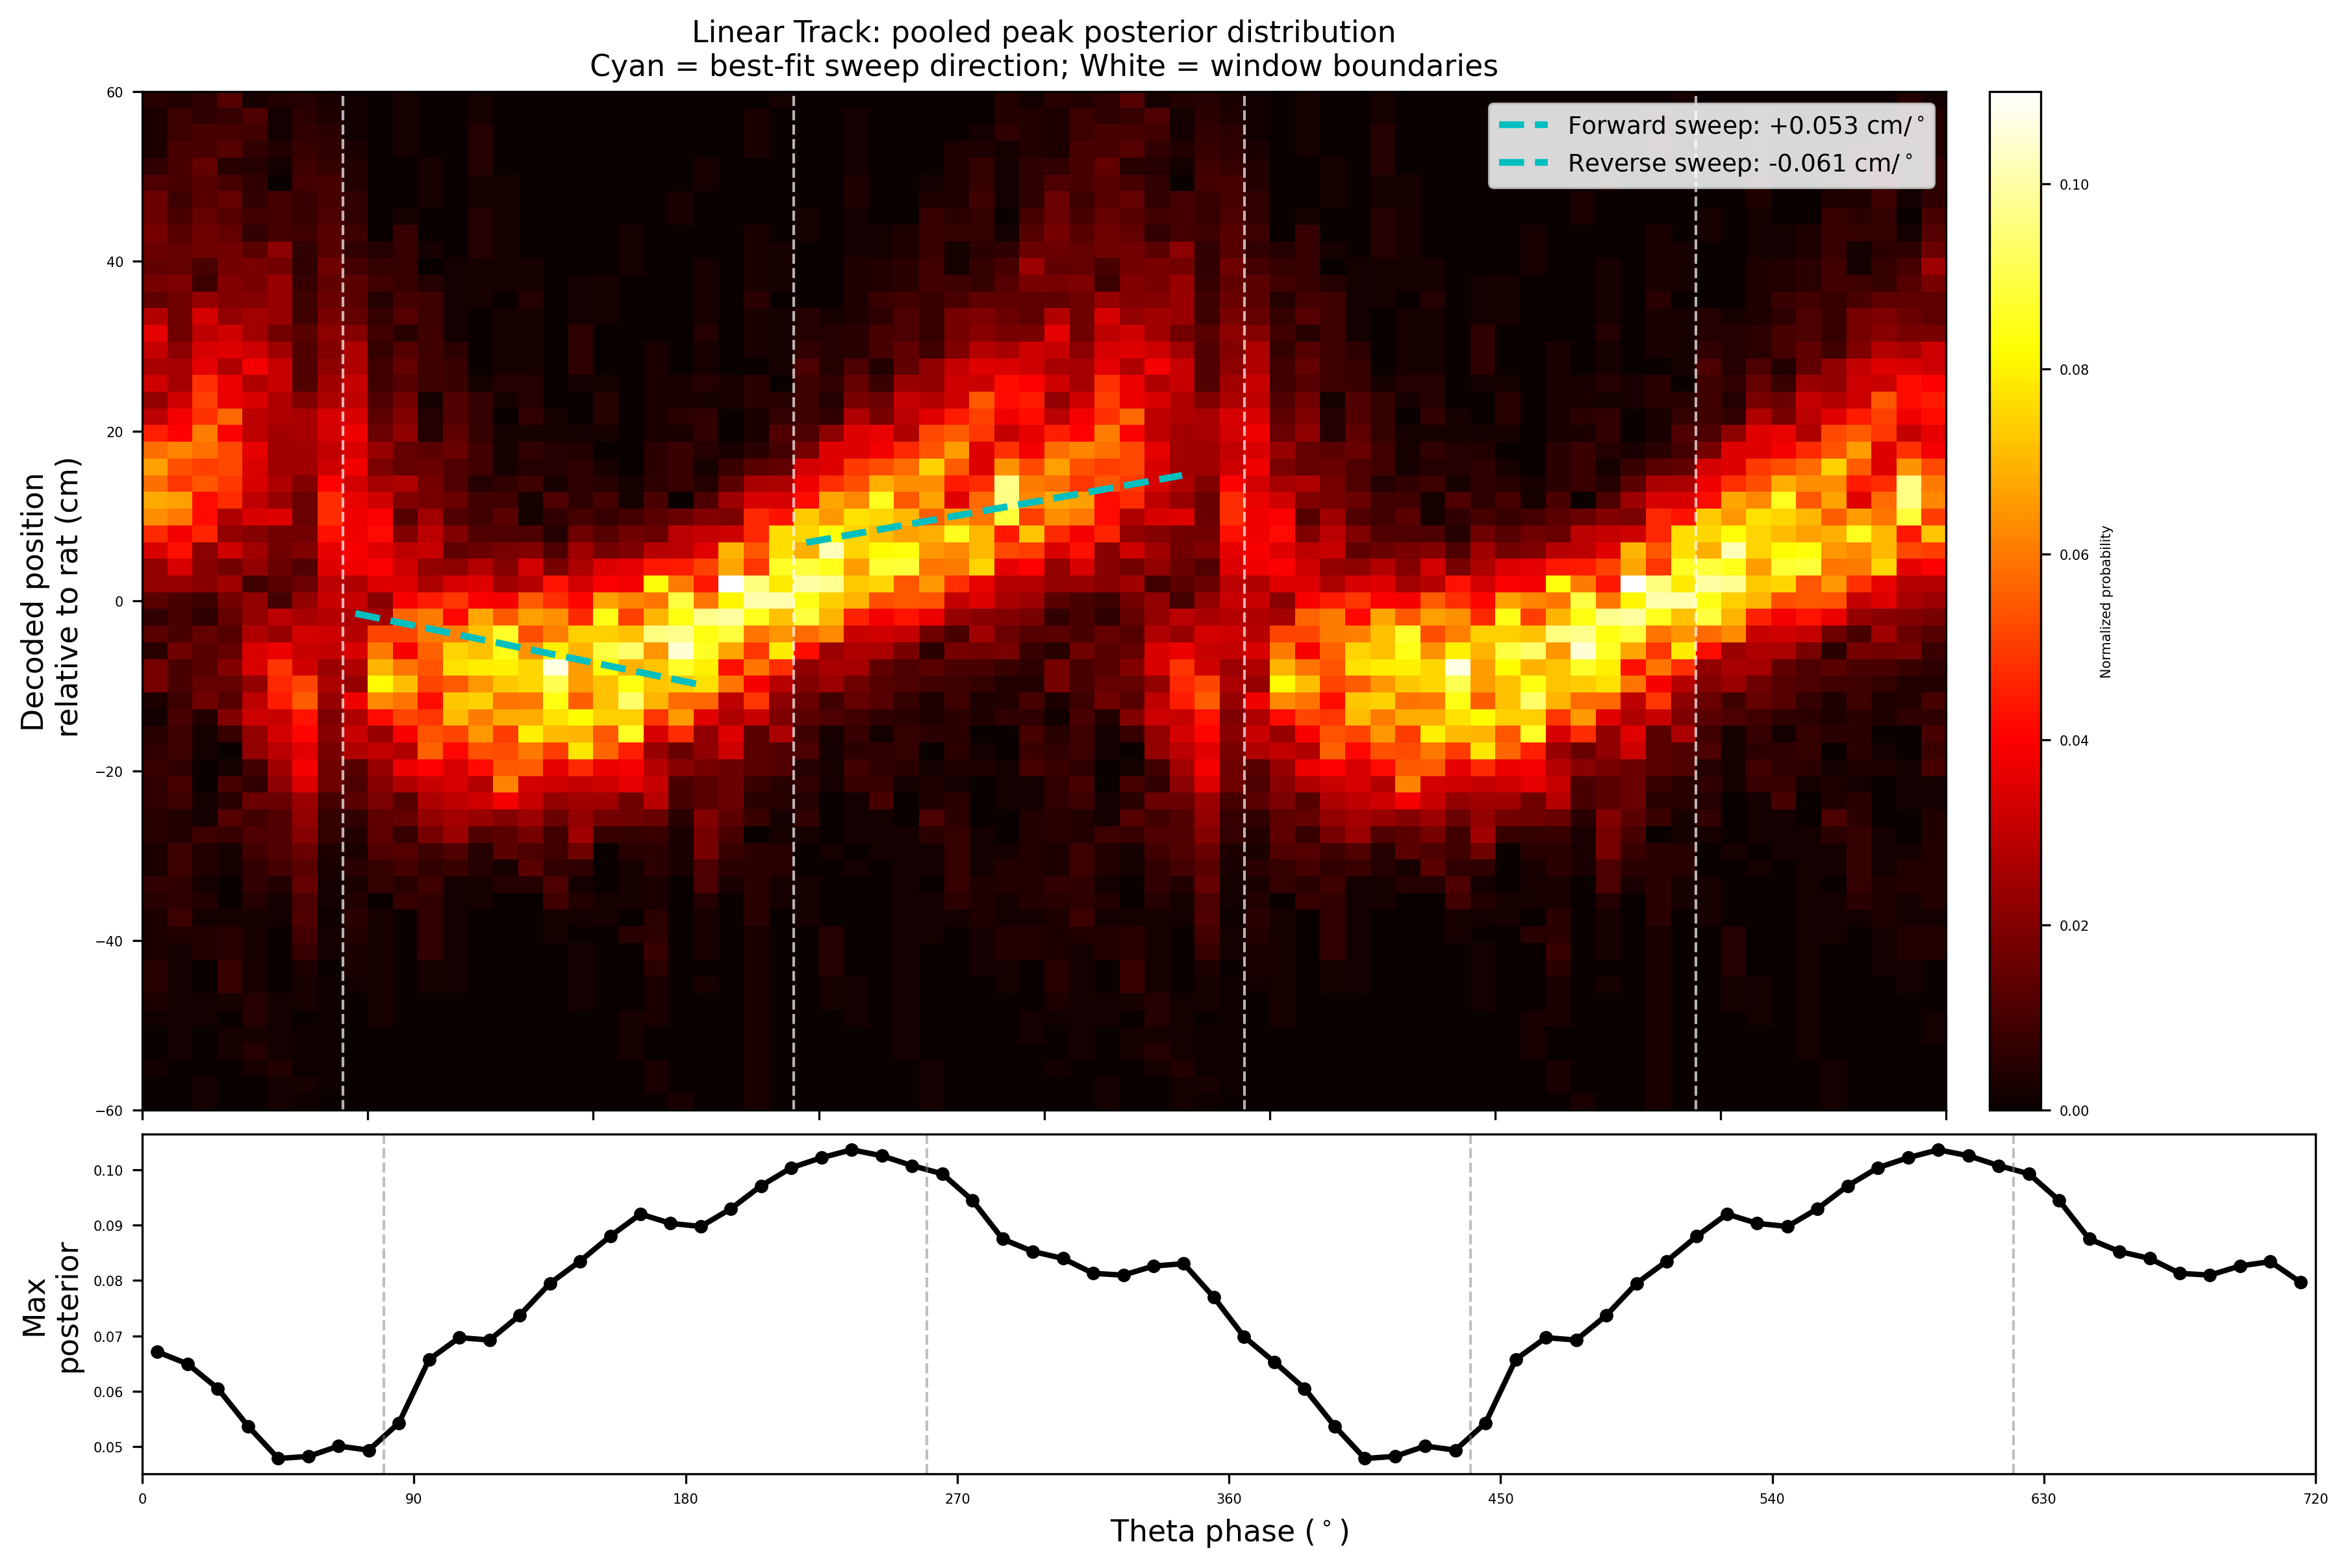

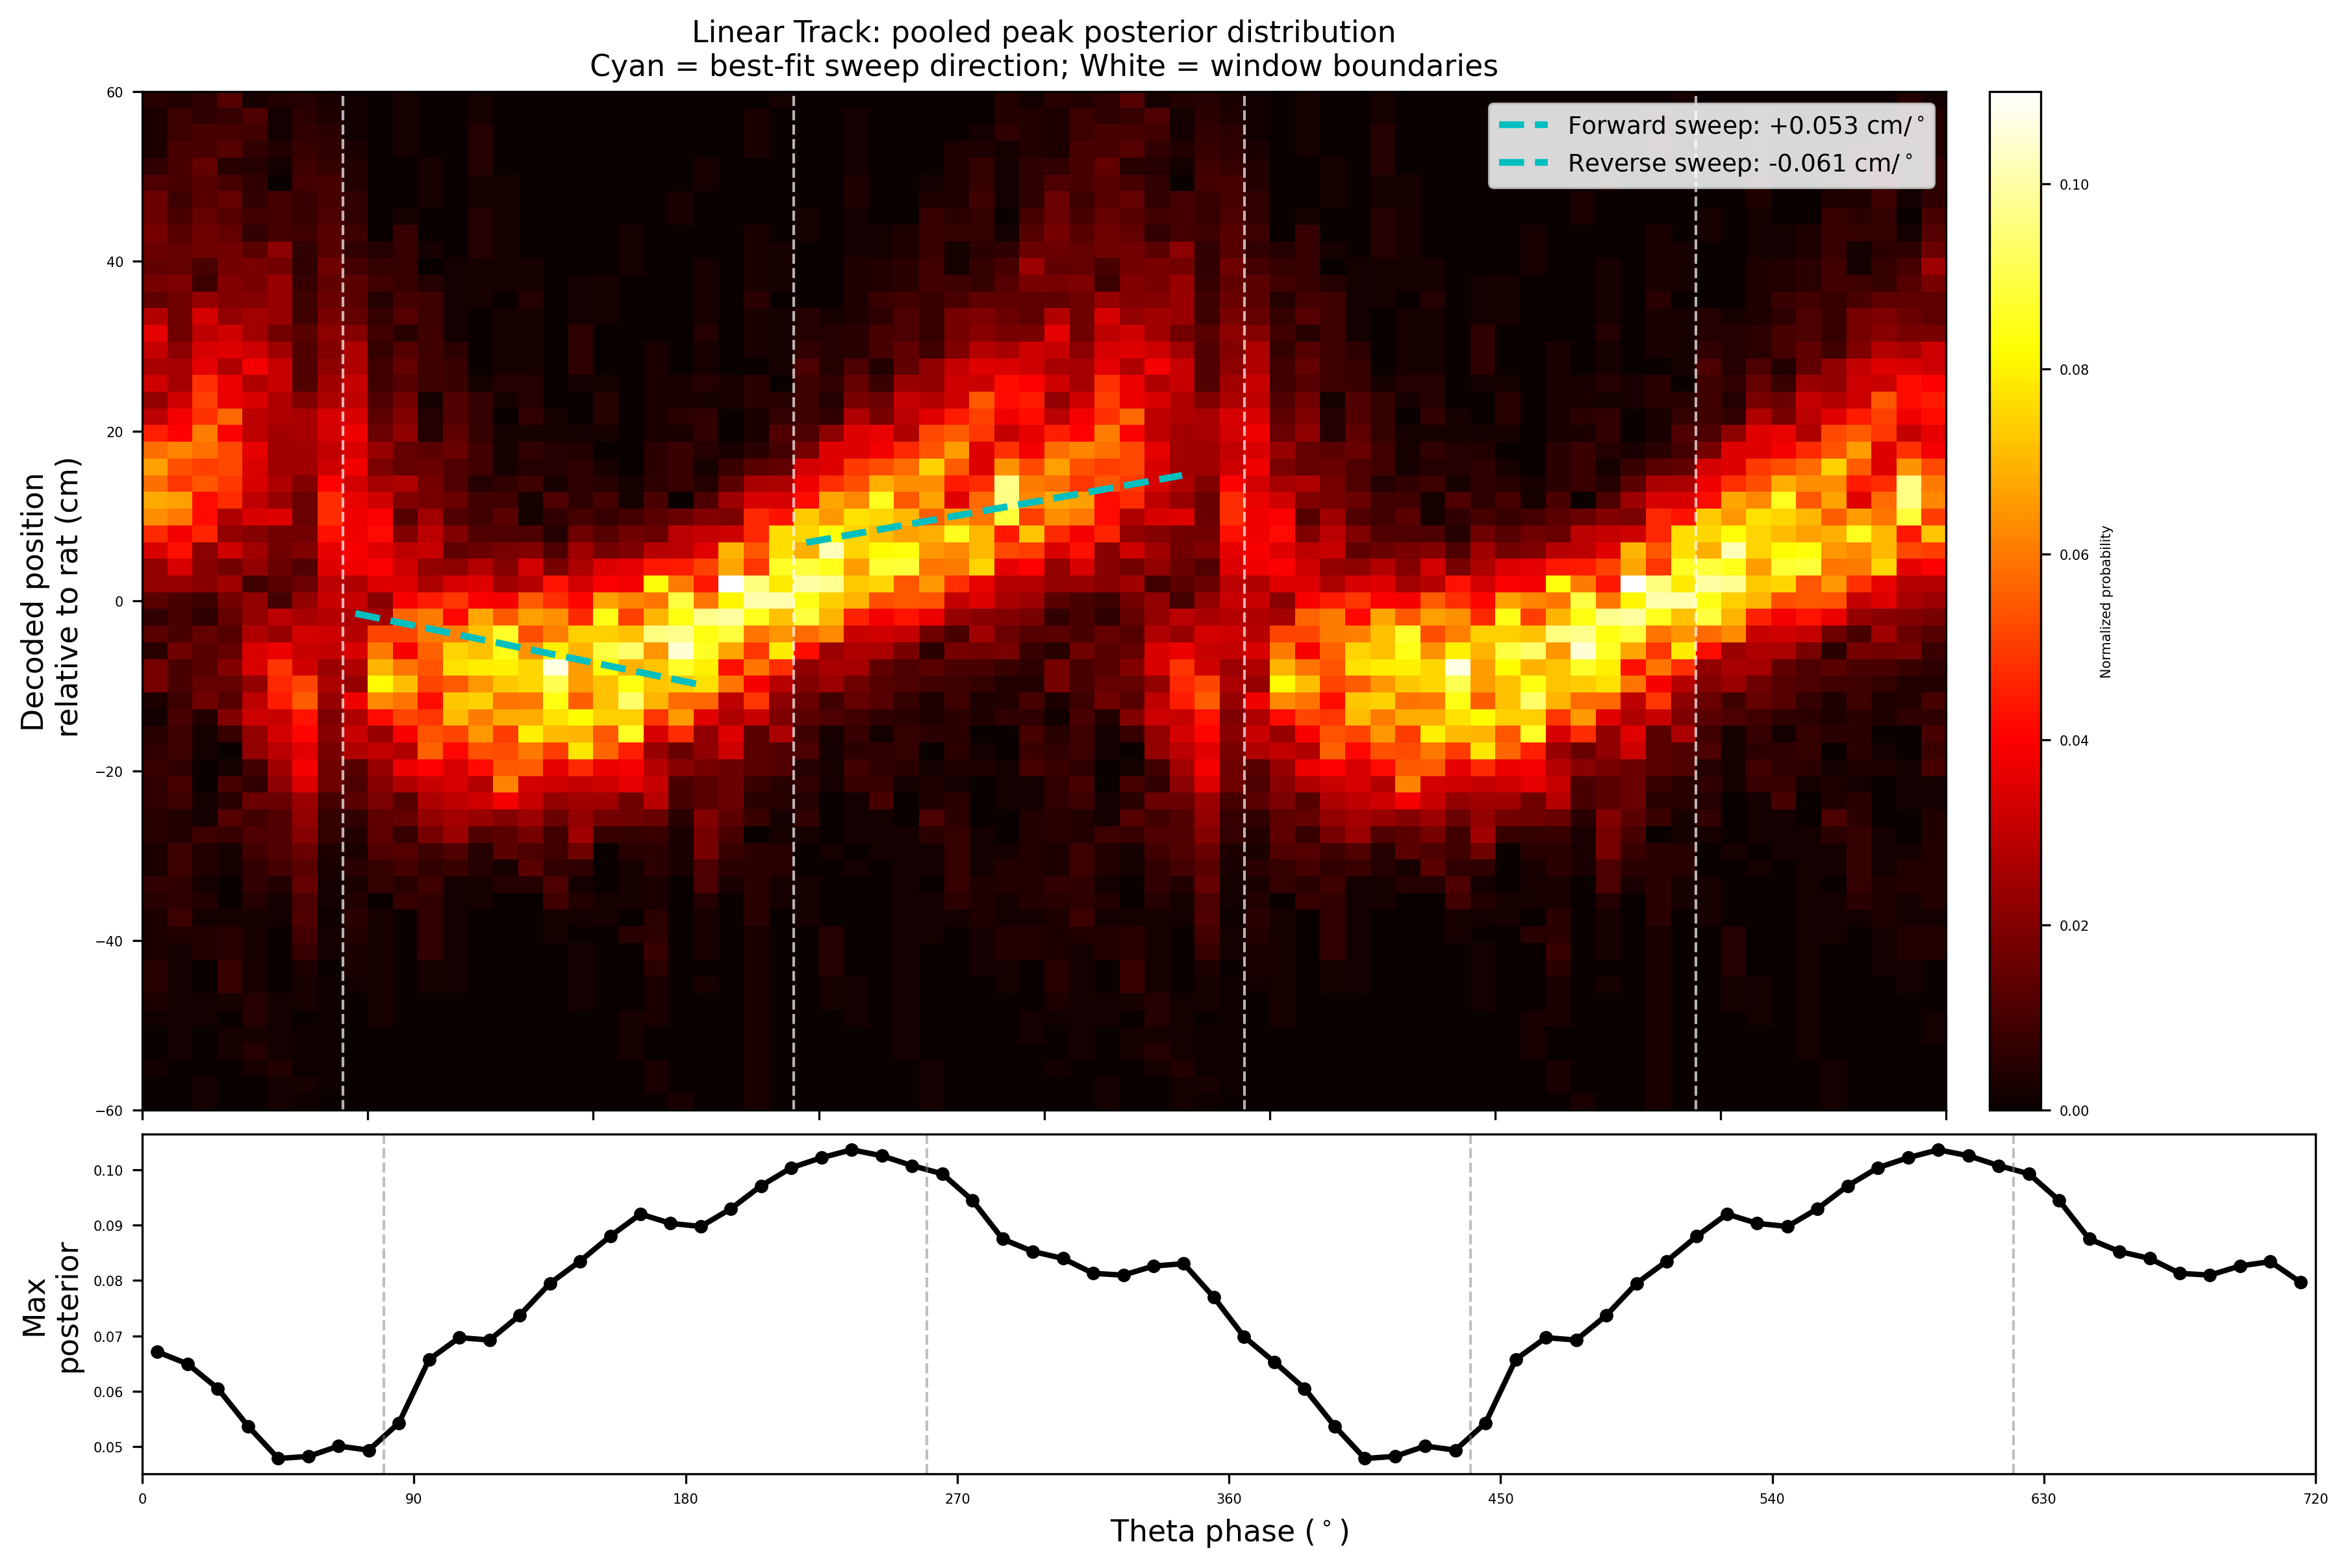

In [ ]:
LMB, V_STD = 20.0, 150.0                      # 50 ms velocity time constant, 150 cm/s
momentum.decay  = torch.log(torch.tensor([LMB], dtype=torch.float64))
momentum.diffusion = torch.log(torch.tensor([V_STD * (2*LMB)**0.5], dtype=torch.float64))

X = momentum._initialize_observations(momentum.approximate_mean)
momentum._initialize_globals("train")
vals, _ = momentum.e_step(momentum._initialize_values(X), mode="train")

ssm_grids = gaussian_to_grid(vals.smoothed_mean, vals.smoothed_cov,
                            raw_data.environment_size, bin_size, momentum.latent_dim)
r_ssm = peak_posterior_new(ssm_grids, raw_data.environment_size,
                            theta_data.ground_truth, theta_data.spikes)
hsepl.plot_across_session_decoding_hist(r_ssm['norm_dist'])